# Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot Per Claim

In [ ]:
for i in range(1, 21):
    claim_str = f"claim{i}"

    # Load your dataframes
    df_agent1 = pd.read_csv(f"refinement_per_claim_final_results/{claim_str}/CN_Creator_Agent_1.csv")
    df_agent2 = pd.read_csv(f"refinement_per_claim_final_results/{claim_str}/CN_Creator_Agent_2.csv")
    df_agent3 = pd.read_csv(f"refinement_per_claim_final_results/{claim_str}/CN_Creator_Agent_3.csv")

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle(f'{claim_str} KPI Average Scores with $\pm$ 1 Std Dev', fontsize=16)

    # Agent 1 Plot (avg_pers)
    # Plot the line connecting the data points
    axes[0].plot(df_agent1.index, df_agent1['avg_pers'], linestyle='-', color='blue', alpha=0.7, label='Avg Persuasiveness')
    # Plot the scatter points with error bars
    axes[0].errorbar(df_agent1.index, df_agent1['avg_pers'], yerr=df_agent1['std_pers'],
                    fmt='o', color='blue', capsize=5, label='_nolegend_') # _nolegend_ prevents duplicate legend entry
    axes[0].set_title('Agent 1: Average Persuasiveness')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Value')
    axes[0].set_ylim(0, 100)  # Set y-axis limits to [0, 100]
    axes[0].set_xticks(df_agent1.index)  # Set x-ticks to be the index of the dataframe
    axes[0].set_yticks(np.arange(0, 101, 10))  # Set y-ticks to be multiples of 10
    axes[0].legend()
    axes[0].grid(True)

    # Agent 2 Plot (avg_emot)
    # Plot the line connecting the data points
    axes[1].plot(df_agent2.index, df_agent2['avg_emot'], linestyle='-', color='green', alpha=0.7, label='Avg Emotional Engagement')
    # Plot the scatter points with error bars
    axes[1].errorbar(df_agent2.index, df_agent2['avg_emot'], yerr=df_agent2['std_emot'],
                    fmt='o', color='green', capsize=5, label='_nolegend_')
    axes[1].set_title('Agent 2: Average Emotional Engagement')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Value')
    axes[1].set_ylim(0, 100)  # Set y-axis limits to [0, 100]
    axes[1].set_xticks(df_agent2.index)  # Set x-ticks to be the index of the dataframe
    axes[1].set_yticks(np.arange(0, 101, 10))  # Set y-ticks to be multiples of 10
    axes[1].legend()
    axes[1].grid(True)

    # Agent 3 Plot (avg_share)
    # Plot the line connecting the data points
    axes[2].plot(df_agent3.index, df_agent3['avg_share'], linestyle='-', color='red', alpha=0.7, label='Avg Shareability')
    # Plot the scatter points with error bars
    axes[2].errorbar(df_agent3.index, df_agent3['avg_share'], yerr=df_agent3['std_share'],
                    fmt='o', color='red', capsize=5, label='_nolegend_')
    axes[2].set_title('Agent 3: Average Shareability')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Value')
    axes[2].set_ylim(0, 100)  # Set y-axis limits to [0, 100]
    axes[2].set_xticks(df_agent3.index)  # Set x-ticks to be the index of the dataframe
    axes[2].set_yticks(np.arange(0, 101, 10))  # Set y-ticks to be multiples of 10
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
    save_path = f"refinement_per_claim_final_results/{claim_str}/plot_per_kpi.png"
    plt.savefig(save_path, dpi=300)

# Refinement Process Plot Per Group and KPI

## **Group 1 - NATO / Western Aggression & Broken Promises**

<tmp>/3312681063.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


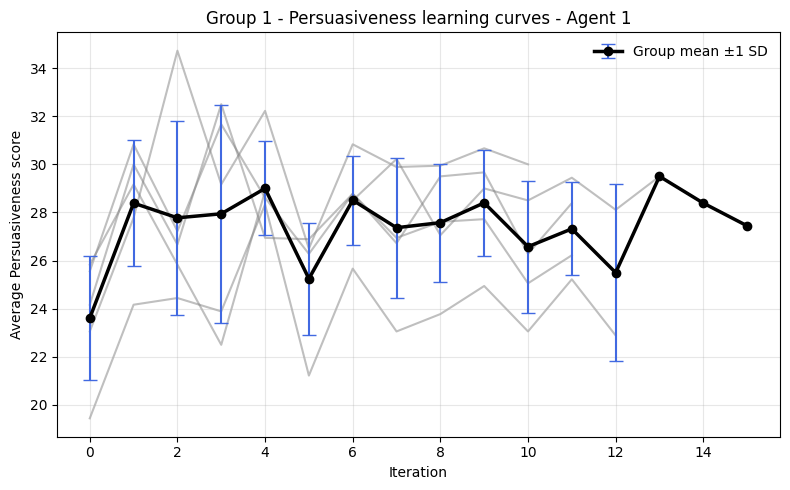

<tmp>/3312681063.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


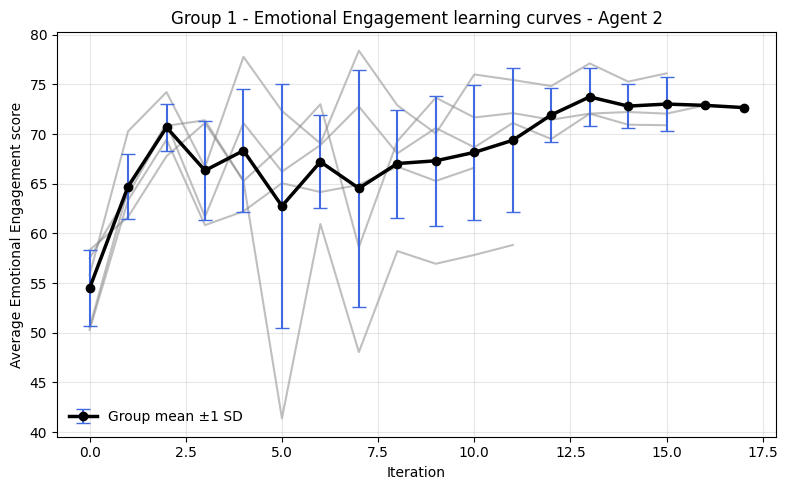

<tmp>/3312681063.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


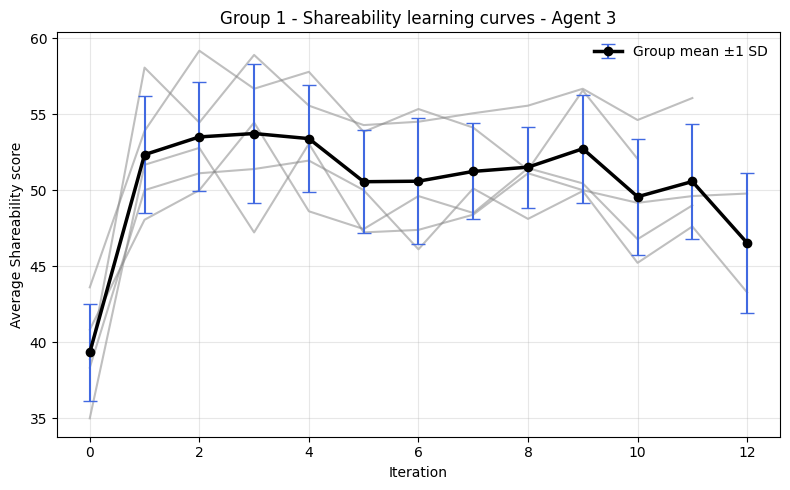

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim1",
    "claim3",
    "claim4",
    "claim15",
    "claim20"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 1 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group1_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

## **Group 2 - Western Manipulation, Hegemony & Moral Decay**

<tmp>/2750911419.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


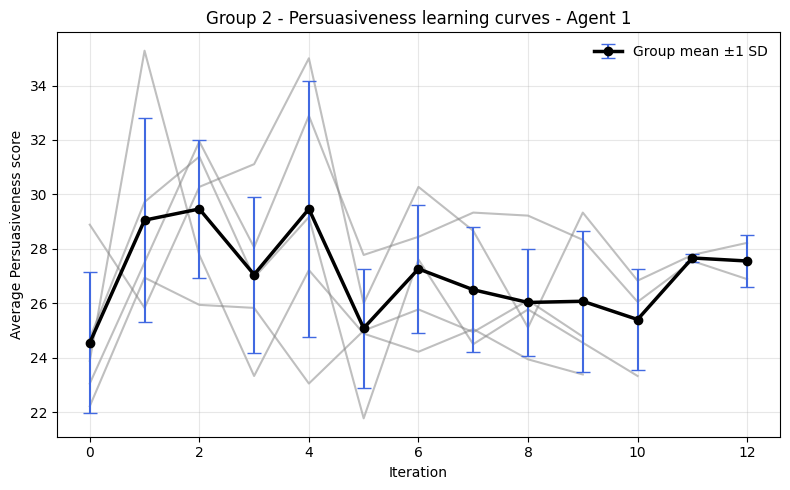

<tmp>/2750911419.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


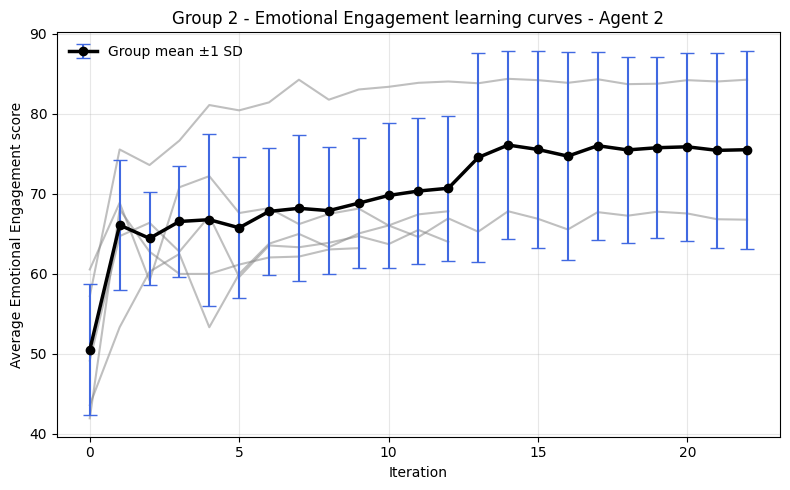

<tmp>/2750911419.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


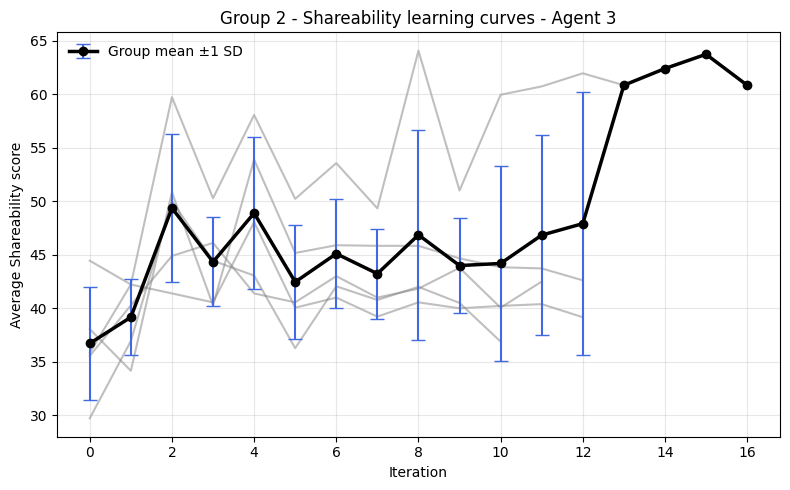

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim9",
    "claim11",
    "claim12",
    "claim13",
    "claim14"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 2 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group2_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

## **Group 3 - Humanitarian / ‘Denazification’ Justifications & Ukraine’s Wrongdoing**

<tmp>/4199370031.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


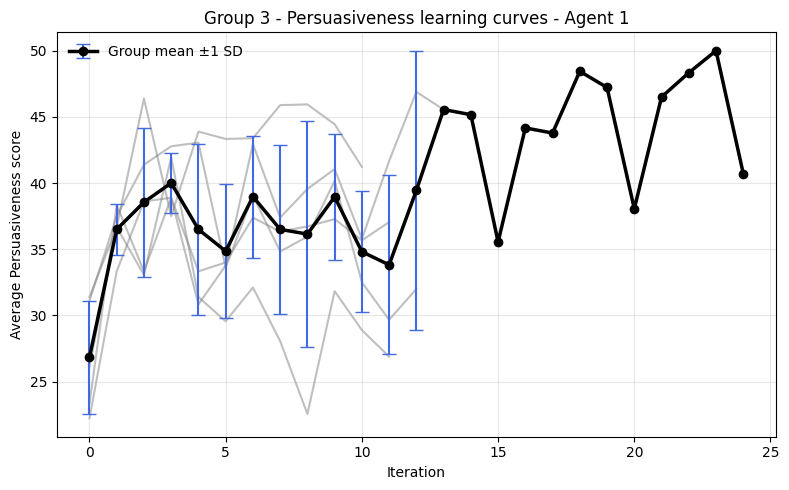

<tmp>/4199370031.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


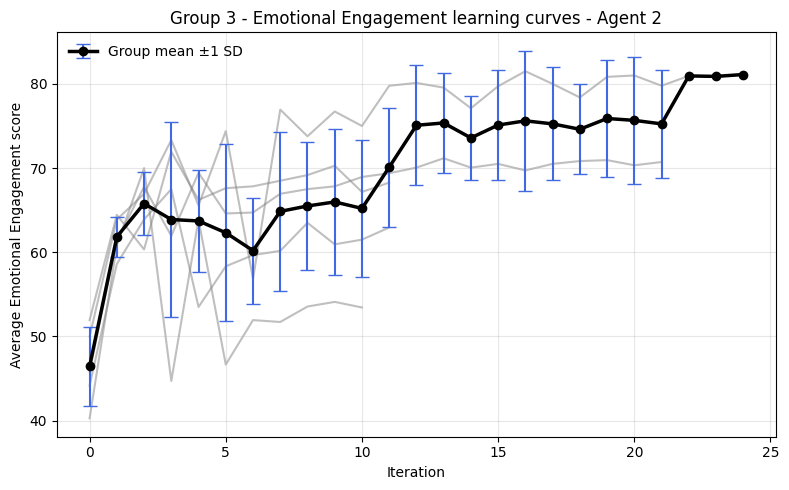

<tmp>/4199370031.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


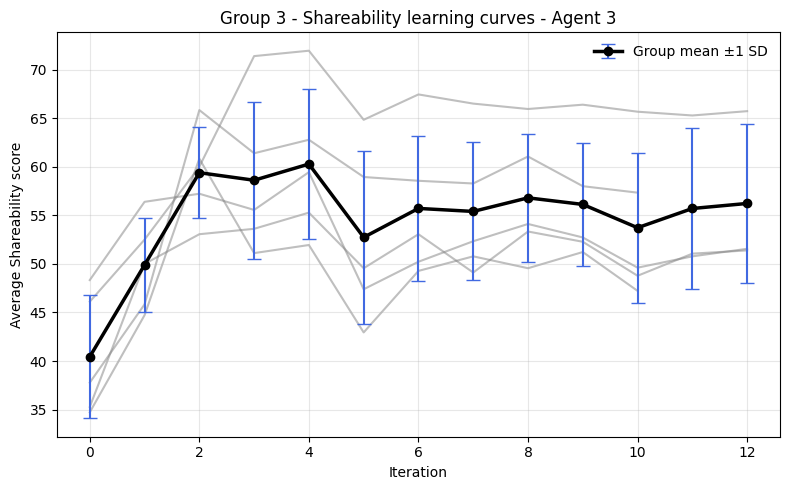

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim2",
    "claim6",
    "claim10",
    "claim16",
    "claim19"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 3 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
        # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group3_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

## **Group 4 - Military Success & Liberation Narrative**

<tmp>/1768448472.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


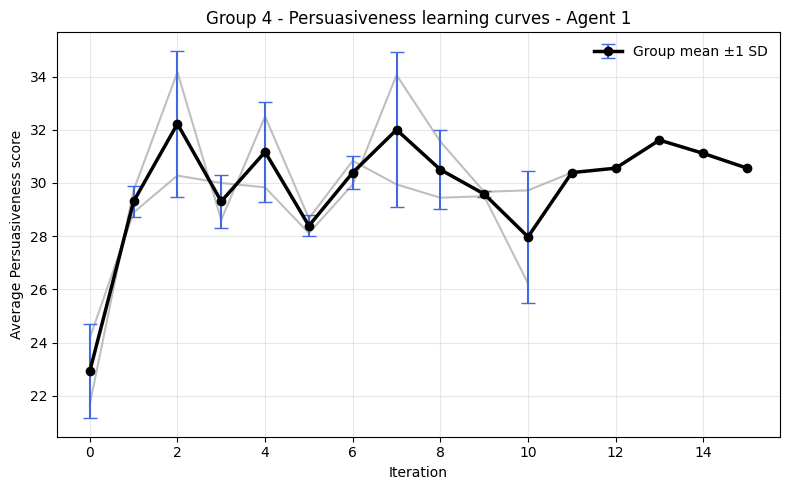

<tmp>/1768448472.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


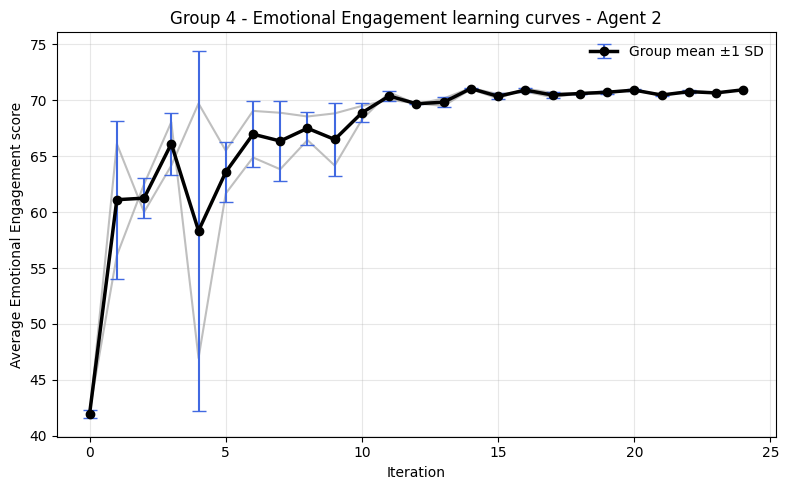

<tmp>/1768448472.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


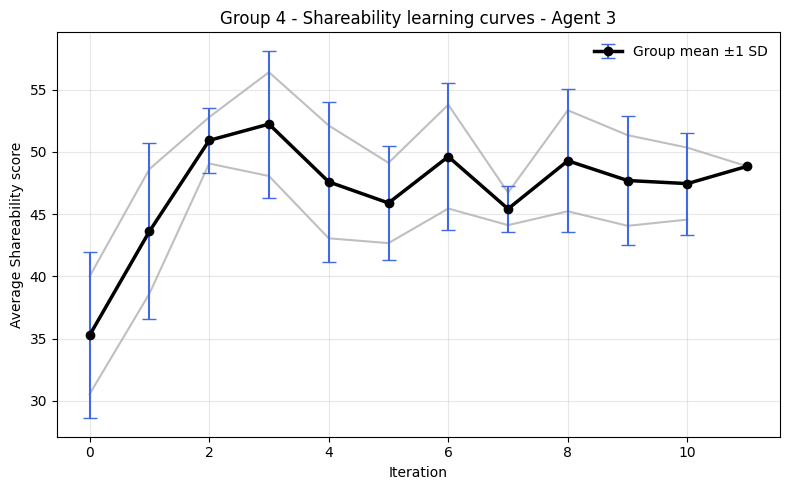

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim5",
    "claim17"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 4 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
        # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group4_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

## **Group 5 - Territorial Legitimacy via Referendum**

<tmp>/2077703463.py:65: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


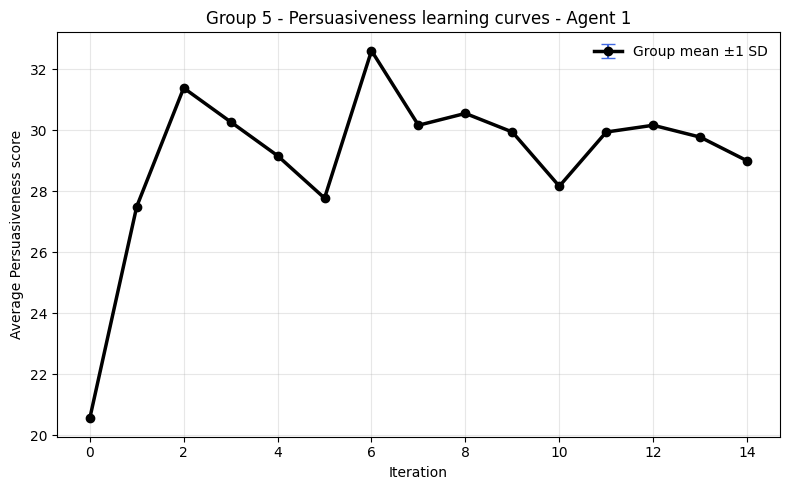

<tmp>/2077703463.py:65: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


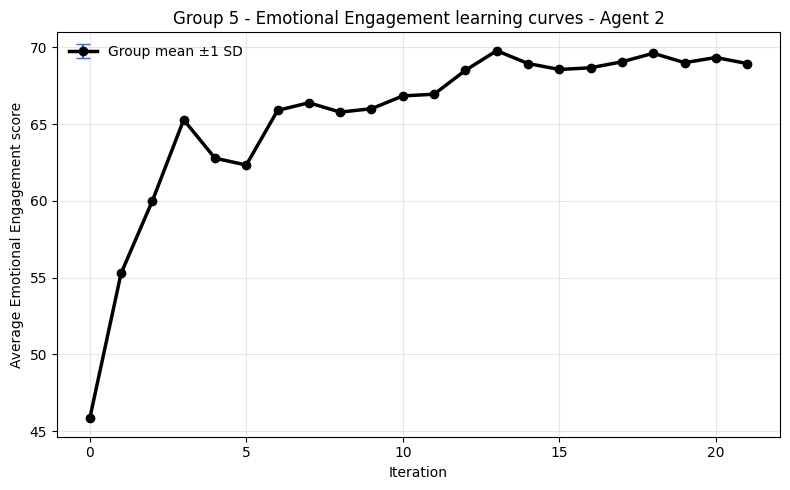

<tmp>/2077703463.py:65: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


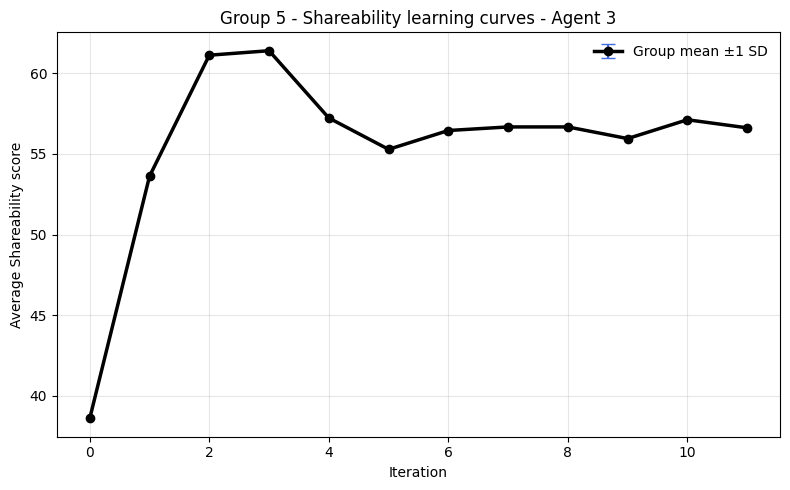

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim8"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 5 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
        # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group5_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

## **Group 6 - Economic‐Warfare & War-Profit Claims**

<tmp>/1756358332.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


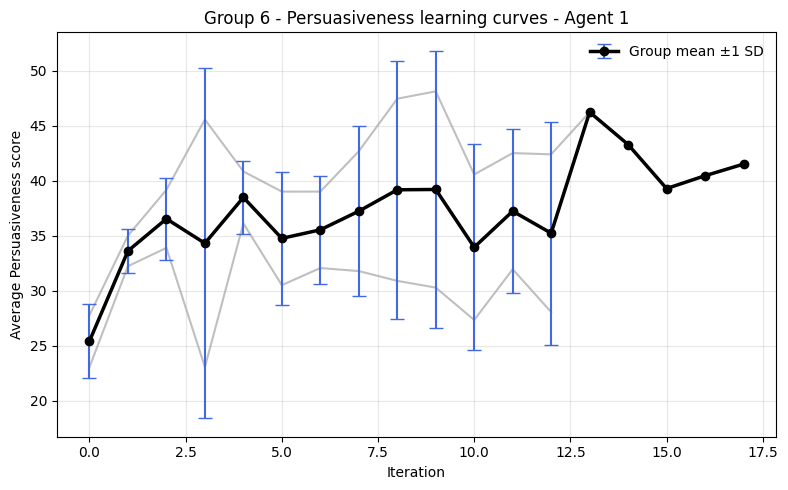

<tmp>/1756358332.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


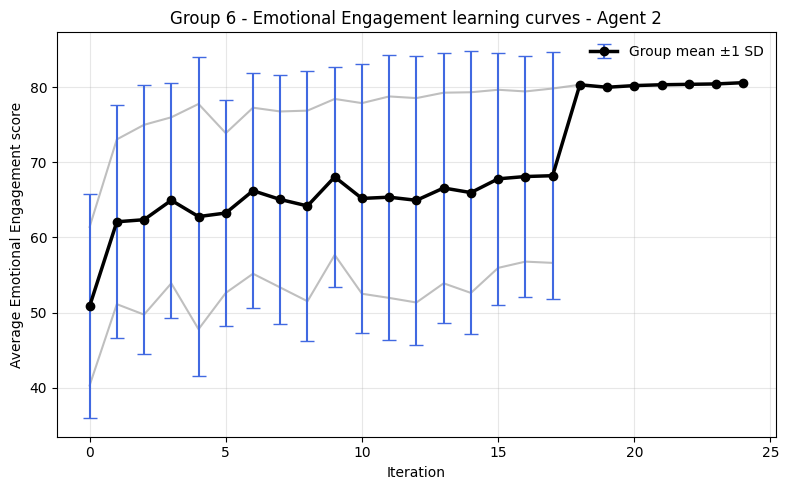

<tmp>/1756358332.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs


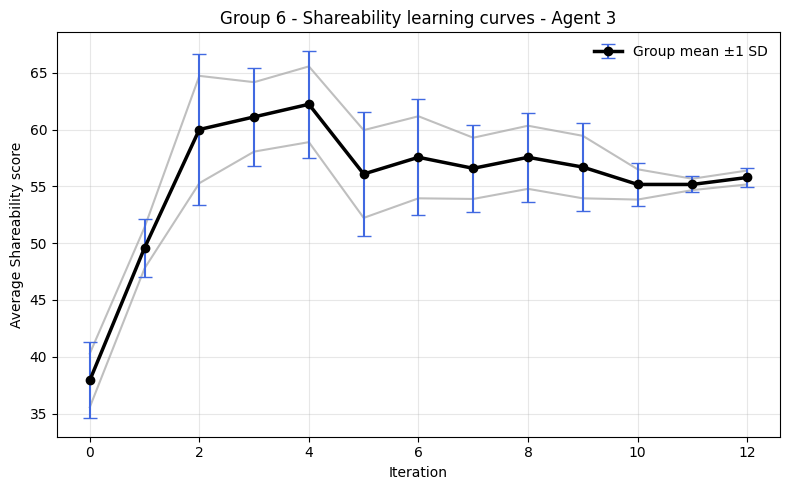

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

claims = [
    "claim7",
    "claim18"
]

avg_cols = {
    1: "avg_pers",
    2: "avg_emot",
    3: "avg_share"
}

kpi_names = {
    1: "Persuasiveness",
    2: "Emotional Engagement",
    3: "Shareability"
}

for i in range(1, 4):
    agent = f"CN_Creator_Agent_{i}"
    file_pattern = "refinement_per_claim_final_results/{claim}/{agent}.csv"

    CLAIM_COL = "claim"
    AVG_COL = avg_cols[i]

    dfs = []
    for claim_val in claims: # Renamed 'claim' to 'claim_val' to avoid conflict with CLAIM_COL
        fp = file_pattern.format(claim=claim_val, agent=agent)
        if Path(fp).exists():
            try:
                df = pd.read_csv(fp)
                if "iteration" not in df.columns:
                    df = df.reset_index().rename(columns={"index": "iteration"})
                
                # Ensure AVG_COL exists in the dataframe
                if AVG_COL not in df.columns:
                    print(f"Warning: Column '{AVG_COL}' not found in {fp}. Skipping this file for KPI '{kpi_names[i]}'.")
                    continue
                # Ensure CLAIM_COL exists or can be created
                if CLAIM_COL not in df.columns:
                     # If 'claim' column doesn't exist, create it using the current claim_val
                    df[CLAIM_COL] = claim_val

                df = df[["iteration", AVG_COL, CLAIM_COL]]
                dfs.append(df)
            except Exception as e:
                print(f"Error reading or processing file {fp}: {e}")
        else:
            print(f"Warning: File not found at {fp}")

    if not dfs:
        print(f"No data loaded for KPI '{kpi_names[i]}' with agent '{agent}'. Skipping plot.")
        continue

    group_df = pd.concat(dfs, ignore_index=True)
    group_df["iteration"] = group_df["iteration"].astype(int)

    # Pad shorter runs with NaNs so every claim spans the same iterations.
    # This ensures that groupby operations later for individual lines work correctly across all iterations.
    group_df = (
        group_df.set_index(["iteration", CLAIM_COL])[AVG_COL]
              .unstack(CLAIM_COL, fill_value=pd.NA) # Columns are now claim IDs
              .stack(dropna=False)                  # Stacks claim IDs back as an index level, keeping NAs
              .reset_index(name=AVG_COL)            # Results in columns: 'iteration', 'level_1' (claim IDs), AVG_COL
    )
    
    # The 'stack' operation above might name the claim identifier column 'level_1'
    # if CLAIM_COL was not the name of the columns index before stacking.
    # Let's ensure the claim column is correctly named CLAIM_COL.
    # The unstack(CLAIM_COL) makes CLAIM_COL the name of the columns index.
    # So, after stack().reset_index(), the column should be named CLAIM_COL.
    # Example: if CLAIM_COL='claim', columns are 'iteration', 'claim', AVG_COL.

    # This check for 'iteration' column name is good
    if "iteration" not in group_df.columns and "level_0" in group_df.columns:
        group_df.rename(columns={"level_0": "iteration"}, inplace=True)
    
    # Ensure the claim identifier column is named CLAIM_COL for consistency
    # It should be correctly named if CLAIM_COL was used in unstack and was a string.
    # If it somehow became 'level_1', we rename it.
    if CLAIM_COL not in group_df.columns and 'level_1' in group_df.columns:
        group_df.rename(columns={'level_1': CLAIM_COL}, inplace=True)


    summary = (
        group_df.groupby("iteration")[AVG_COL]
                .agg(["mean", "std"])
                .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Thin grey lines for each claim
    # Make sure to group by the actual column name for claims in group_df
    for claim_id, sub_df in group_df.groupby(CLAIM_COL):
        sub_df_sorted = sub_df.sort_values("iteration") # Sort by iteration for correct line plotting
        ax.plot(sub_df_sorted["iteration"], sub_df_sorted[AVG_COL],
                lw=1.5, color="grey", alpha=0.5, zorder=1, label='_nolegend_') # Use label='_nolegend_' to hide from legend

    # 2) Plot the group mean with error bars
    ax.errorbar(summary["iteration"], summary["mean"], yerr=summary["std"],
                fmt='-o',
                color="black",          # Color of the main line
                mfc="black",            # Marker Face Color
                mec="black",            # Marker Edge Color
                ecolor="royalblue",     # Color of the error bars
                lw=2.5,
                elinewidth=1.5,
                capsize=5,
                label="Group mean ±1 SD", # This will appear in the legend
                zorder=2)

    # Cosmetics
    ax.set_title(f"Group 6 - {kpi_names[i]} learning curves - Agent {agent.split('_')[-1]}") # Adjusted title for clarity
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Average {kpi_names[i]} score")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
        # Save the figure before showing
    output_dir = Path("group_analysis_results/refinement_per_group")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"group6_{avg_cols[i]}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

# Improvements Per Group and KPI

## **KPI 1 - Persuasiveness**

--- Processing Claims for KPI: avg_pers ---


--- Analysis for Metric: Improvement Slope (avg_pers/Iteration) ---


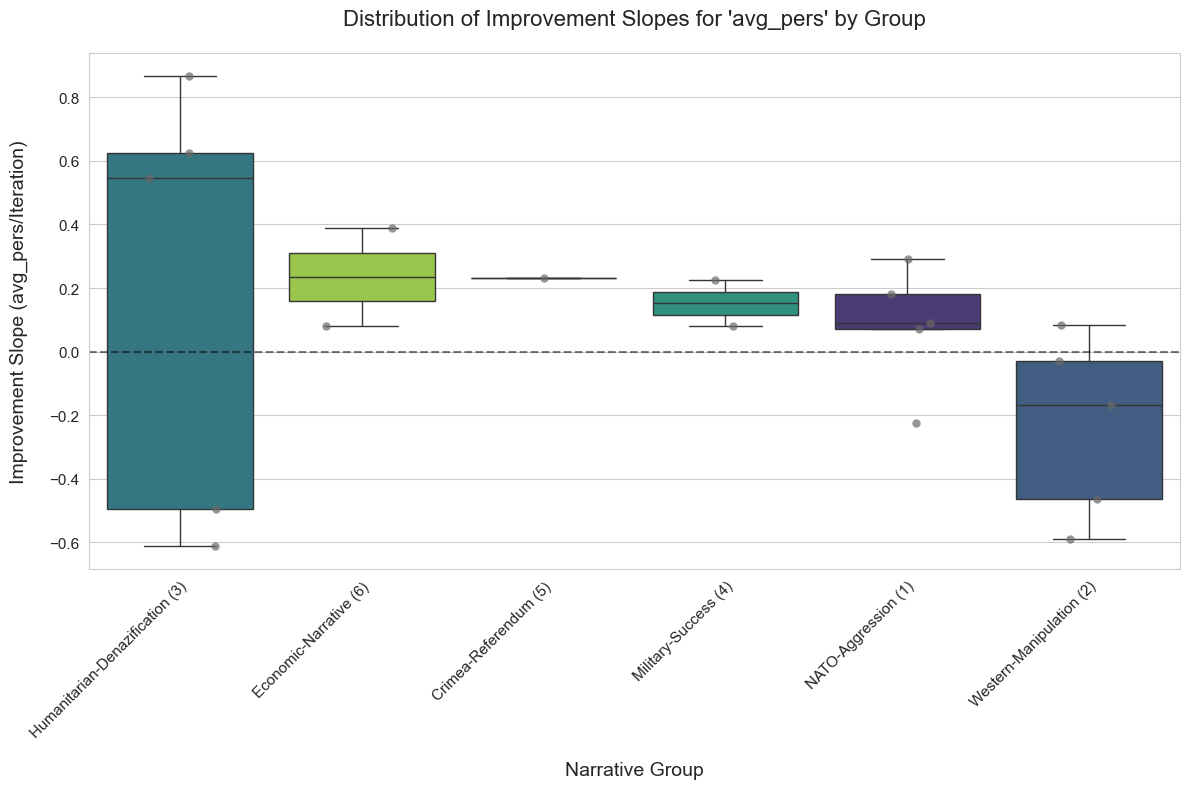


--- Statistical Test for Improvement Slope (avg_pers/Iteration) ---
Kruskal–Wallis Test (comparing median improvement slope (avg_pers/iteration) across groups):
H-statistic = 4.469,  p-value = 0.4841
Overall Kruskal-Wallis (improvement slope (avg_pers/iteration)) p-value >= 0.05, Dunn's test not performed.


--- Analysis for Metric: Delta (Avg Peak 3 - Avg Early 3) ---


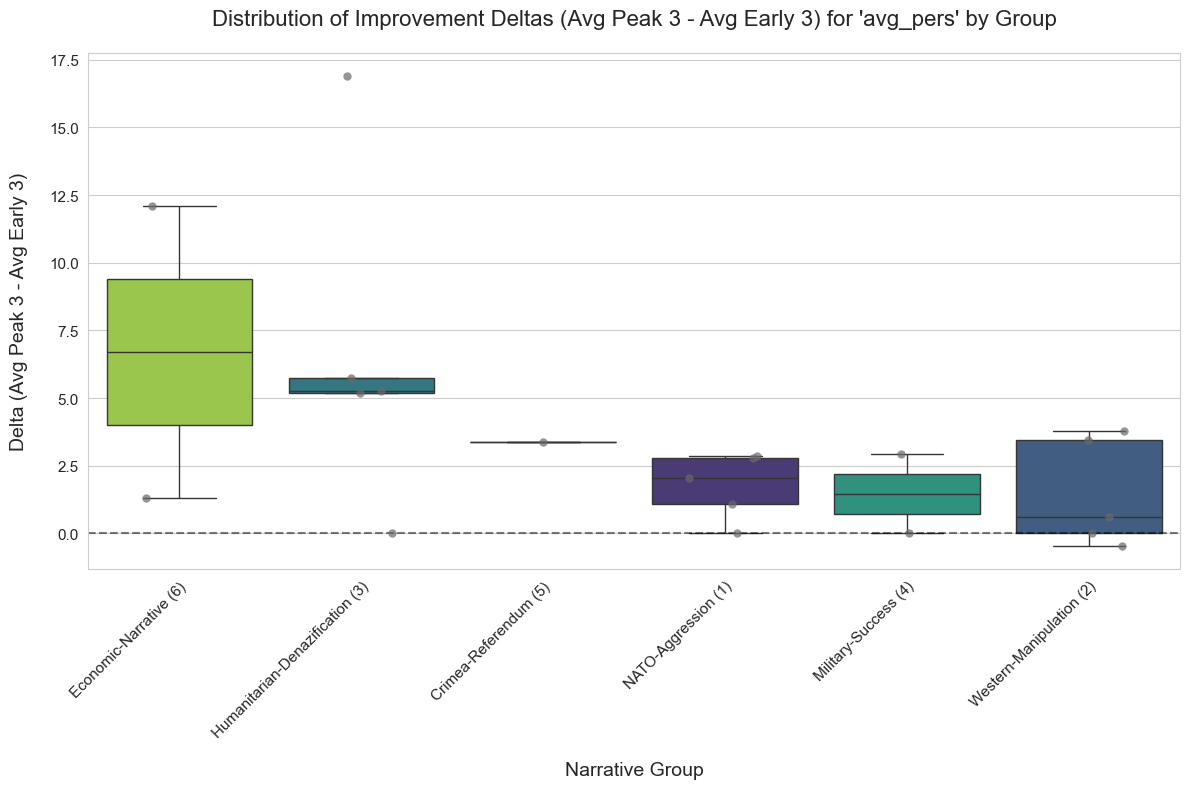


--- Statistical Test for Delta (Avg Peak 3 - Avg Early 3) ---
Kruskal–Wallis Test (comparing median delta (avg peak 3 - avg early 3) across groups):
H-statistic = 5.722,  p-value = 0.3342
Overall Kruskal-Wallis (delta (avg peak 3 - avg early 3)) p-value >= 0.05, Dunn's test not performed.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
import scikit_posthocs as sp
import numpy as np

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)": ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)": ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)": ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)": ["claim7", "claim18"],
}

agent = "CN_Creator_Agent_1" # Or dynamically set if needed
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

# Column in CSV containing the scores to analyze
SCORE_COL_IN_CSV = "avg_pers" # << SET YOUR TARGET KPI COLUMN HERE

# --- Metric A: Slope ---
SLOPE_COL_DF = "improvement_slope"
POTENTIAL_ITERATION_COL_NAMES = ["iteration", "Iteration", "step", "Step", "round", "Round", "Unnamed: 0", "index"]

# --- Metric C: Delta (Mean Peak Window - Mean Early Window) ---
DELTA_COL_DF = "delta_early_peak_avg"
N_WINDOW_FOR_DELTA = 3 # Window size for early and peak scores (e.g., 3 iterations)
MIN_VALID_SCORES_FOR_DELTA = 1 # Min non-NaN scores a claim needs to attempt delta calculation
# ----------------------------

analysis_rows = []
print(f"--- Processing Claims for KPI: {SCORE_COL_IN_CSV} ---")
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        
        slope_value = np.nan
        delta_value = np.nan
        
        try:
            df = pd.read_csv(fp)

            if SCORE_COL_IN_CSV not in df.columns:
                print(f"INFO: Score column '{SCORE_COL_IN_CSV}' not found for claim '{claim_id}' in {fp}. Skipping.")
                analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: slope_value, DELTA_COL_DF: delta_value})
                continue
            
            df[SCORE_COL_IN_CSV] = pd.to_numeric(df[SCORE_COL_IN_CSV], errors='coerce')

            # --- Calculate Metric A: Slope ---
            iteration_col_to_use = None
            for col_name in POTENTIAL_ITERATION_COL_NAMES:
                if col_name in df.columns:
                    iteration_col_to_use = col_name
                    break
            
            if iteration_col_to_use:
                df["current_iteration_numeric"] = pd.to_numeric(df[iteration_col_to_use], errors='coerce')
            else:
                df = df.reset_index()
                df.rename(columns={"index": "current_iteration_numeric"}, inplace=True)
            
            claim_data_for_slope = df[["current_iteration_numeric", SCORE_COL_IN_CSV]].dropna()
            if len(claim_data_for_slope) >= 2 and claim_data_for_slope["current_iteration_numeric"].nunique() >= 2:
                slope_res = stats.linregress(
                    x=claim_data_for_slope["current_iteration_numeric"],
                    y=claim_data_for_slope[SCORE_COL_IN_CSV]
                )
                slope_value = slope_res.slope
            else:
                print(f"INFO: Claim '{claim_id}' has < 2 valid/distinct data points for slope. Slope set to NaN.")

            # --- Calculate Metric C: Delta (Mean Peak Window - Mean Early Window) ---
            scores_numeric_for_delta = df[SCORE_COL_IN_CSV].dropna().reset_index(drop=True)

            if len(scores_numeric_for_delta) >= MIN_VALID_SCORES_FOR_DELTA:
                mean_early = scores_numeric_for_delta.iloc[0:min(N_WINDOW_FOR_DELTA, len(scores_numeric_for_delta))].mean()
                
                idx_max_in_numeric = scores_numeric_for_delta.idxmax()
                
                peak_window_start_idx = max(0, idx_max_in_numeric - N_WINDOW_FOR_DELTA + 1)
                peak_window_end_idx = idx_max_in_numeric + 1
                mean_peak_window = scores_numeric_for_delta.iloc[peak_window_start_idx:peak_window_end_idx].mean()
                
                if pd.notna(mean_early) and pd.notna(mean_peak_window):
                    delta_value = mean_peak_window - mean_early
                else:
                    print(f"INFO: Could not compute valid early or peak mean for delta for claim '{claim_id}'. Delta set to NaN.")
            else:
                print(f"INFO: Claim '{claim_id}' has < {MIN_VALID_SCORES_FOR_DELTA} valid scores for delta. Delta set to NaN.")

            analysis_rows.append({
                "group": group_name,
                "claim": claim_id,
                SLOPE_COL_DF: slope_value,
                DELTA_COL_DF: delta_value
            })

        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except pd.errors.EmptyDataError:
            print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except Exception as e:
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})

analysis_df = pd.DataFrame(analysis_rows)

# ----- Function to Plot and Analyze a Metric -----
def plot_and_analyze_metric(df, metric_col, metric_name_display, score_col_csv, higher_is_better=True):
    print(f"\n\n--- Analysis for Metric: {metric_name_display} ---")
    
    df_plottable = df.dropna(subset=[metric_col])

    if not df_plottable.empty and df_plottable['group'].nunique() > 0:
        plt.figure(figsize=(12, 8))
        sns.set_style("whitegrid")
        
        group_order = df_plottable.groupby('group')[metric_col].median().sort_values(ascending=(not higher_is_better)).index
        
        ax = sns.boxplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            hue="group", whis=1.5, fliersize=0, legend=False, palette="viridis", dodge=False
        )
        sns.stripplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            ax=ax, size=6, jitter=0.2, color="dimgray", alpha=0.7
        )

        title_suffix = "Improvement Slopes" if "slope" in metric_col else f"Improvement Deltas (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})"
        ax.set_title(f"Distribution of {title_suffix} for '{score_col_csv}' by Group", fontsize=16, pad=20)
        ax.set_xlabel("Narrative Group", fontsize=14, labelpad=15)
        ax.set_ylabel(f"{metric_name_display}", fontsize=14, labelpad=15)
        
        ax.tick_params(axis='x', labelsize=11)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.tick_params(axis='y', labelsize=11)
        if "slope" in metric_col or "delta" in metric_col: # Add horizontal line for slope or delta plots
             ax.axhline(0, ls='--', color='black', alpha=0.5) 
        
        plt.tight_layout()

        # --- Save plot ---
        save_dir = Path("group_analysis_results/improvement_per_group")
        save_dir.mkdir(parents=True, exist_ok=True)
        # Clean metric_col for filename
        metric_col_clean = metric_col.replace(" ", "_").replace("/", "_")
        score_col_clean = score_col_csv.replace(" ", "_").replace("/", "_")
        plot_filename = f"{metric_col_clean}_{score_col_clean}.png"
        plt.savefig(save_dir / plot_filename, dpi=300, bbox_inches="tight")

        plt.show()

        # Statistical Analysis
        print(f"\n--- Statistical Test for {metric_name_display} ---")
        df_cleaned_for_stats = df_plottable # Already dropped NaNs for this metric_col
        
        if df_cleaned_for_stats['group'].nunique() > 1 and df_cleaned_for_stats.groupby('group')[metric_col].count().min() >= 1:
            print(f"Kruskal–Wallis Test (comparing median {metric_name_display.lower()} across groups):")
            samples = [
                group_data[metric_col].values 
                for name, group_data in df_cleaned_for_stats.groupby("group")
                if len(group_data[metric_col]) > 0
            ]
            
            if len(samples) >= 2:
                try:
                    H_stat, p_kw = stats.kruskal(*samples)
                    print(f"H-statistic = {H_stat:.3f},  p-value = {p_kw:.4g}")

                    if p_kw < 0.05:
                        print(f"\nPairwise Dunn Test (Holm-corrected p-values for {metric_name_display.lower()}):")
                        dunn_results = sp.posthoc_dunn(df_cleaned_for_stats, 
                                                       val_col=metric_col,
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha_dunn = 0.05
                        mask_dunn = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)
                        sig_pairs_dunn = (
                            dunn_results.where(mask_dunn)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha_dunn")
                                .sort_values("p_value")
                        )

                        if sig_pairs_dunn.empty:
                            print(f"No pairwise differences in {metric_name_display.lower()} survive Holm correction.")
                        else:
                            for _, row in sig_pairs_dunn.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"  {g1} vs {g2}   →   p = {p_val:.3g}")
                    else:
                        print(f"Overall Kruskal-Wallis ({metric_name_display.lower()}) p-value >= 0.05, Dunn's test not performed.")
                except ValueError as ve_kruskal:
                    print(f"INFO: Kruskal-Wallis test for {metric_name_display.lower()} could not be performed. Error: {ve_kruskal}.")
            else:
                print(f"INFO: Less than 2 groups with valid {metric_name_display.lower()} data for Kruskal-Wallis test.")
        else:
            print(f"No valid {metric_name_display.lower()} data or not enough groups to perform statistical tests.")
    else:
        print(f"No valid data available to plot or analyze for metric: {metric_name_display}.")

# --- Analyze Metric A: Improvement Slope ---
plot_and_analyze_metric(analysis_df, SLOPE_COL_DF, f"Improvement Slope ({SCORE_COL_IN_CSV}/Iteration)", SCORE_COL_IN_CSV, higher_is_better=True)

# --- Analyze Metric C: Delta (Early vs Peak Avg) ---
plot_and_analyze_metric(analysis_df, DELTA_COL_DF, f"Delta (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})", SCORE_COL_IN_CSV, higher_is_better=True)

## **KPI 2 - Emotional Engagement**

--- Processing Claims for KPI: avg_emot ---


--- Analysis for Metric: Improvement Slope (avg_emot/Iteration) ---


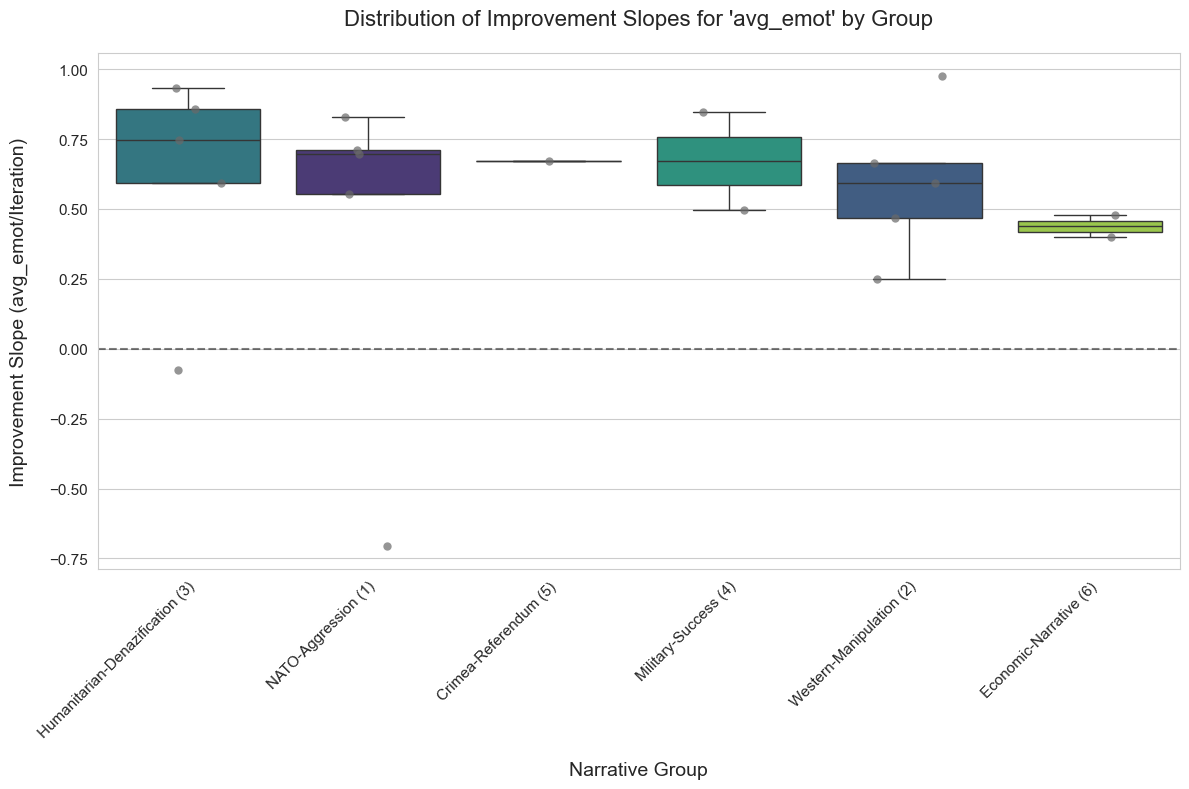


--- Statistical Test for Improvement Slope (avg_emot/Iteration) ---
Kruskal–Wallis Test (comparing median improvement slope (avg_emot/iteration) across groups):
H-statistic = 2.794,  p-value = 0.7317
Overall Kruskal-Wallis (improvement slope (avg_emot/iteration)) p-value >= 0.05, Dunn's test not performed.


--- Analysis for Metric: Delta (Avg Peak 3 - Avg Early 3) ---


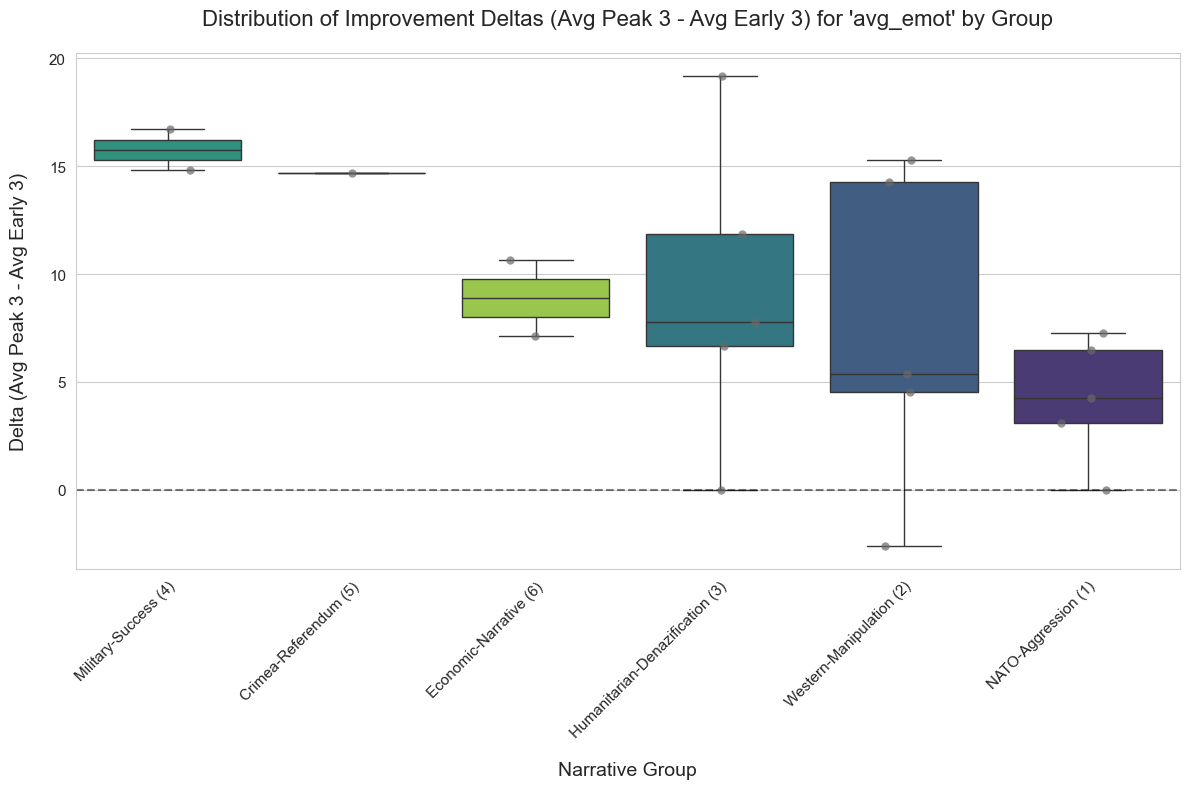


--- Statistical Test for Delta (Avg Peak 3 - Avg Early 3) ---
Kruskal–Wallis Test (comparing median delta (avg peak 3 - avg early 3) across groups):
H-statistic = 7.223,  p-value = 0.2046
Overall Kruskal-Wallis (delta (avg peak 3 - avg early 3)) p-value >= 0.05, Dunn's test not performed.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
# from statsmodels.stats.multicomp import pairwise_tukeyhsd # Optional for ANOVA
# import statsmodels.formula.api as smf # Optional for ANOVA
# import statsmodels.api as sm # Optional for ANOVA
import scikit_posthocs as sp
import numpy as np

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)": ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)": ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)": ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)": ["claim7", "claim18"],
}

agent = "CN_Creator_Agent_2" # Or dynamically set if needed
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

# Column in CSV containing the scores to analyze
SCORE_COL_IN_CSV = "avg_emot" # << SET YOUR TARGET KPI COLUMN HERE

# --- Metric A: Slope ---
SLOPE_COL_DF = "improvement_slope"
POTENTIAL_ITERATION_COL_NAMES = ["iteration", "Iteration", "step", "Step", "round", "Round", "Unnamed: 0", "index"]

# --- Metric C: Delta (Mean Peak Window - Mean Early Window) ---
DELTA_COL_DF = "delta_early_peak_avg"
N_WINDOW_FOR_DELTA = 3 # Window size for early and peak scores (e.g., 3 iterations)
MIN_VALID_SCORES_FOR_DELTA = 1 # Min non-NaN scores a claim needs to attempt delta calculation
# ----------------------------

analysis_rows = []
print(f"--- Processing Claims for KPI: {SCORE_COL_IN_CSV} ---")
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        
        slope_value = np.nan
        delta_value = np.nan
        
        try:
            df = pd.read_csv(fp)

            if SCORE_COL_IN_CSV not in df.columns:
                print(f"INFO: Score column '{SCORE_COL_IN_CSV}' not found for claim '{claim_id}' in {fp}. Skipping.")
                analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: slope_value, DELTA_COL_DF: delta_value})
                continue
            
            df[SCORE_COL_IN_CSV] = pd.to_numeric(df[SCORE_COL_IN_CSV], errors='coerce')

            # --- Calculate Metric A: Slope ---
            iteration_col_to_use = None
            for col_name in POTENTIAL_ITERATION_COL_NAMES:
                if col_name in df.columns:
                    iteration_col_to_use = col_name
                    break
            
            if iteration_col_to_use:
                df["current_iteration_numeric"] = pd.to_numeric(df[iteration_col_to_use], errors='coerce')
            else:
                df = df.reset_index()
                df.rename(columns={"index": "current_iteration_numeric"}, inplace=True)
            
            claim_data_for_slope = df[["current_iteration_numeric", SCORE_COL_IN_CSV]].dropna()
            if len(claim_data_for_slope) >= 2 and claim_data_for_slope["current_iteration_numeric"].nunique() >= 2:
                slope_res = stats.linregress(
                    x=claim_data_for_slope["current_iteration_numeric"],
                    y=claim_data_for_slope[SCORE_COL_IN_CSV]
                )
                slope_value = slope_res.slope
            else:
                print(f"INFO: Claim '{claim_id}' has < 2 valid/distinct data points for slope. Slope set to NaN.")

            # --- Calculate Metric C: Delta (Mean Peak Window - Mean Early Window) ---
            scores_numeric_for_delta = df[SCORE_COL_IN_CSV].dropna().reset_index(drop=True)

            if len(scores_numeric_for_delta) >= MIN_VALID_SCORES_FOR_DELTA:
                mean_early = scores_numeric_for_delta.iloc[0:min(N_WINDOW_FOR_DELTA, len(scores_numeric_for_delta))].mean()
                
                idx_max_in_numeric = scores_numeric_for_delta.idxmax()
                
                peak_window_start_idx = max(0, idx_max_in_numeric - N_WINDOW_FOR_DELTA + 1)
                peak_window_end_idx = idx_max_in_numeric + 1
                mean_peak_window = scores_numeric_for_delta.iloc[peak_window_start_idx:peak_window_end_idx].mean()
                
                if pd.notna(mean_early) and pd.notna(mean_peak_window):
                    delta_value = mean_peak_window - mean_early
                else:
                    print(f"INFO: Could not compute valid early or peak mean for delta for claim '{claim_id}'. Delta set to NaN.")
            else:
                print(f"INFO: Claim '{claim_id}' has < {MIN_VALID_SCORES_FOR_DELTA} valid scores for delta. Delta set to NaN.")

            analysis_rows.append({
                "group": group_name,
                "claim": claim_id,
                SLOPE_COL_DF: slope_value,
                DELTA_COL_DF: delta_value
            })

        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except pd.errors.EmptyDataError:
            print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except Exception as e:
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})

analysis_df = pd.DataFrame(analysis_rows)

# ----- Function to Plot and Analyze a Metric -----
def plot_and_analyze_metric(df, metric_col, metric_name_display, score_col_csv, higher_is_better=True):
    print(f"\n\n--- Analysis for Metric: {metric_name_display} ---")
    
    df_plottable = df.dropna(subset=[metric_col])

    if not df_plottable.empty and df_plottable['group'].nunique() > 0:
        plt.figure(figsize=(12, 8))
        sns.set_style("whitegrid")
        
        group_order = df_plottable.groupby('group')[metric_col].median().sort_values(ascending=(not higher_is_better)).index
        
        ax = sns.boxplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            hue="group", whis=1.5, fliersize=0, legend=False, palette="viridis", dodge=False
        )
        sns.stripplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            ax=ax, size=6, jitter=0.2, color="dimgray", alpha=0.7
        )

        title_suffix = "Improvement Slopes" if "slope" in metric_col else f"Improvement Deltas (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})"
        ax.set_title(f"Distribution of {title_suffix} for '{score_col_csv}' by Group", fontsize=16, pad=20)
        ax.set_xlabel("Narrative Group", fontsize=14, labelpad=15)
        ax.set_ylabel(f"{metric_name_display}", fontsize=14, labelpad=15)
        
        ax.tick_params(axis='x', labelsize=11)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.tick_params(axis='y', labelsize=11)
        if "slope" in metric_col or "delta" in metric_col: # Add horizontal line for slope or delta plots
             ax.axhline(0, ls='--', color='black', alpha=0.5) 
        
        plt.tight_layout()

        # --- Save plot ---
        save_dir = Path("group_analysis_results/improvement_per_group")
        save_dir.mkdir(parents=True, exist_ok=True)
        # Clean metric_col for filename
        metric_col_clean = metric_col.replace(" ", "_").replace("/", "_")
        score_col_clean = score_col_csv.replace(" ", "_").replace("/", "_")
        plot_filename = f"{metric_col_clean}_{score_col_clean}.png"
        plt.savefig(save_dir / plot_filename, dpi=300, bbox_inches="tight")
    
        plt.show()

        # Statistical Analysis
        print(f"\n--- Statistical Test for {metric_name_display} ---")
        df_cleaned_for_stats = df_plottable # Already dropped NaNs for this metric_col
        
        if df_cleaned_for_stats['group'].nunique() > 1 and df_cleaned_for_stats.groupby('group')[metric_col].count().min() >= 1:
            print(f"Kruskal–Wallis Test (comparing median {metric_name_display.lower()} across groups):")
            samples = [
                group_data[metric_col].values 
                for name, group_data in df_cleaned_for_stats.groupby("group")
                if len(group_data[metric_col]) > 0
            ]
            
            if len(samples) >= 2:
                try:
                    H_stat, p_kw = stats.kruskal(*samples)
                    print(f"H-statistic = {H_stat:.3f},  p-value = {p_kw:.4g}")

                    if p_kw < 0.05:
                        print(f"\nPairwise Dunn Test (Holm-corrected p-values for {metric_name_display.lower()}):")
                        dunn_results = sp.posthoc_dunn(df_cleaned_for_stats, 
                                                       val_col=metric_col,
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha_dunn = 0.05
                        mask_dunn = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)
                        sig_pairs_dunn = (
                            dunn_results.where(mask_dunn)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha_dunn")
                                .sort_values("p_value")
                        )

                        if sig_pairs_dunn.empty:
                            print(f"No pairwise differences in {metric_name_display.lower()} survive Holm correction.")
                        else:
                            for _, row in sig_pairs_dunn.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"  {g1} vs {g2}   →   p = {p_val:.3g}")
                    else:
                        print(f"Overall Kruskal-Wallis ({metric_name_display.lower()}) p-value >= 0.05, Dunn's test not performed.")
                except ValueError as ve_kruskal:
                    print(f"INFO: Kruskal-Wallis test for {metric_name_display.lower()} could not be performed. Error: {ve_kruskal}.")
            else:
                print(f"INFO: Less than 2 groups with valid {metric_name_display.lower()} data for Kruskal-Wallis test.")
        else:
            print(f"No valid {metric_name_display.lower()} data or not enough groups to perform statistical tests.")
    else:
        print(f"No valid data available to plot or analyze for metric: {metric_name_display}.")

# --- Analyze Metric A: Improvement Slope ---
plot_and_analyze_metric(analysis_df, SLOPE_COL_DF, f"Improvement Slope ({SCORE_COL_IN_CSV}/Iteration)", SCORE_COL_IN_CSV, higher_is_better=True)

# --- Analyze Metric C: Delta (Early vs Peak Avg) ---
plot_and_analyze_metric(analysis_df, DELTA_COL_DF, f"Delta (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})", SCORE_COL_IN_CSV, higher_is_better=True)

## **KPI 3 - Shareability**

--- Processing Claims for KPI: avg_share ---


--- Analysis for Metric: Improvement Slope (avg_share/Iteration) ---


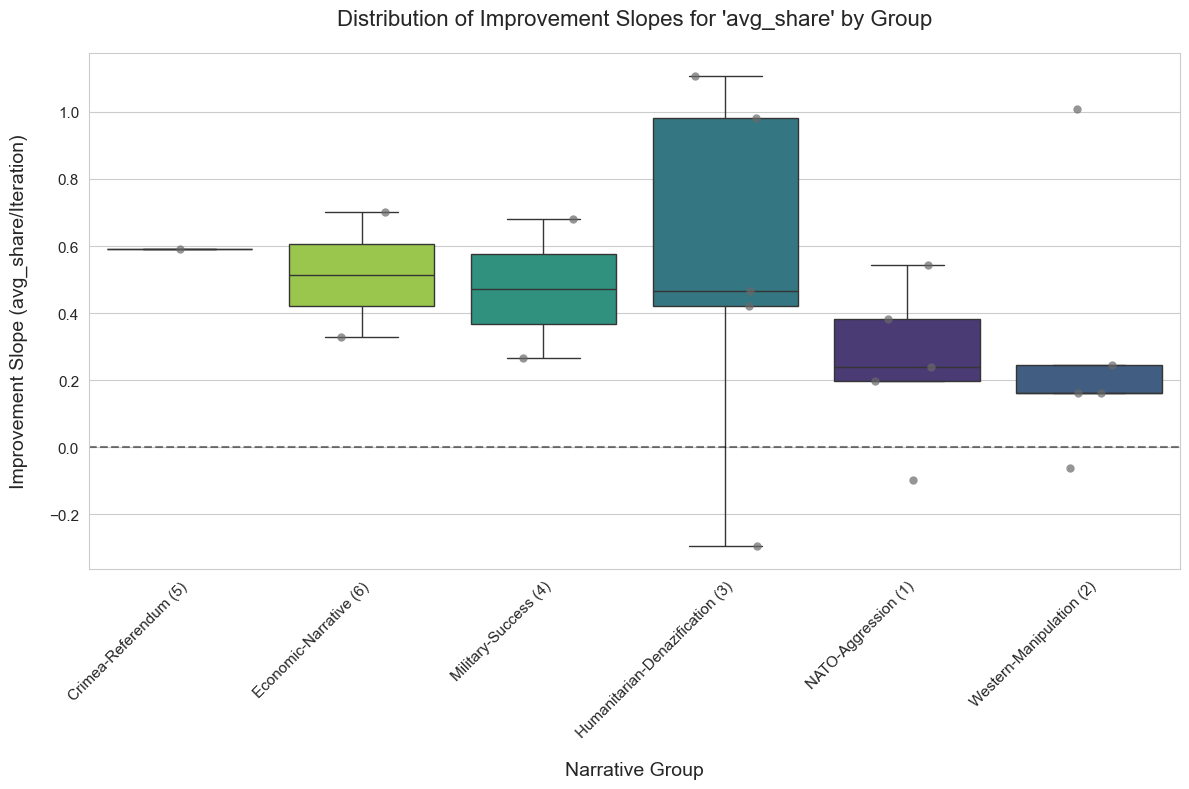


--- Statistical Test for Improvement Slope (avg_share/Iteration) ---
Kruskal–Wallis Test (comparing median improvement slope (avg_share/iteration) across groups):
H-statistic = 4.011,  p-value = 0.5478
Overall Kruskal-Wallis (improvement slope (avg_share/iteration)) p-value >= 0.05, Dunn's test not performed.


--- Analysis for Metric: Delta (Avg Peak 3 - Avg Early 3) ---


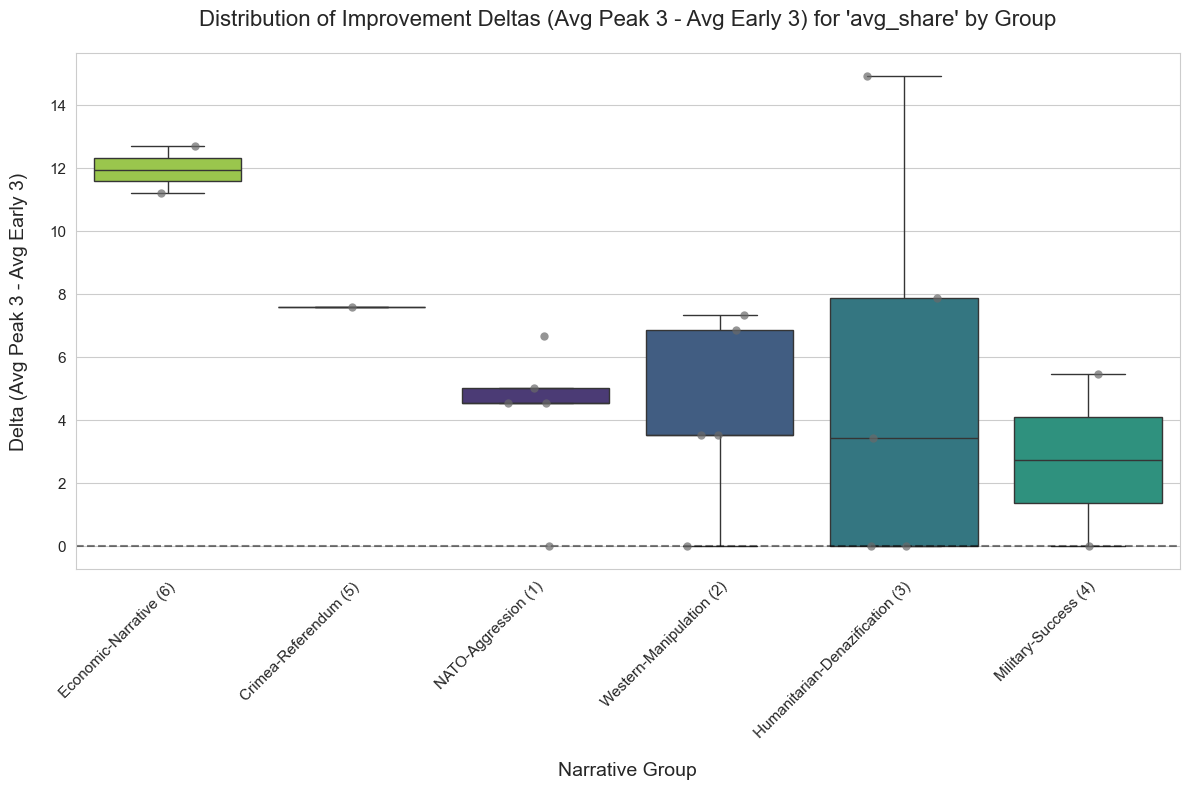


--- Statistical Test for Delta (Avg Peak 3 - Avg Early 3) ---
Kruskal–Wallis Test (comparing median delta (avg peak 3 - avg early 3) across groups):
H-statistic = 5.613,  p-value = 0.3457
Overall Kruskal-Wallis (delta (avg peak 3 - avg early 3)) p-value >= 0.05, Dunn's test not performed.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
# from statsmodels.stats.multicomp import pairwise_tukeyhsd # Optional for ANOVA
# import statsmodels.formula.api as smf # Optional for ANOVA
# import statsmodels.api as sm # Optional for ANOVA
import scikit_posthocs as sp
import numpy as np

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)": ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)": ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)": ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)": ["claim7", "claim18"],
}

agent = "CN_Creator_Agent_3" # Or dynamically set if needed
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

# Column in CSV containing the scores to analyze
SCORE_COL_IN_CSV = "avg_share" # << SET YOUR TARGET KPI COLUMN HERE

# --- Metric A: Slope ---
SLOPE_COL_DF = "improvement_slope"
POTENTIAL_ITERATION_COL_NAMES = ["iteration", "Iteration", "step", "Step", "round", "Round", "Unnamed: 0", "index"]

# --- Metric C: Delta (Mean Peak Window - Mean Early Window) ---
DELTA_COL_DF = "delta_early_peak_avg"
N_WINDOW_FOR_DELTA = 3 # Window size for early and peak scores (e.g., 3 iterations)
MIN_VALID_SCORES_FOR_DELTA = 1 # Min non-NaN scores a claim needs to attempt delta calculation
# ----------------------------

analysis_rows = []
print(f"--- Processing Claims for KPI: {SCORE_COL_IN_CSV} ---")
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        
        slope_value = np.nan
        delta_value = np.nan
        
        try:
            df = pd.read_csv(fp)

            if SCORE_COL_IN_CSV not in df.columns:
                print(f"INFO: Score column '{SCORE_COL_IN_CSV}' not found for claim '{claim_id}' in {fp}. Skipping.")
                analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: slope_value, DELTA_COL_DF: delta_value})
                continue
            
            df[SCORE_COL_IN_CSV] = pd.to_numeric(df[SCORE_COL_IN_CSV], errors='coerce')

            # --- Calculate Metric A: Slope ---
            iteration_col_to_use = None
            for col_name in POTENTIAL_ITERATION_COL_NAMES:
                if col_name in df.columns:
                    iteration_col_to_use = col_name
                    break
            
            if iteration_col_to_use:
                df["current_iteration_numeric"] = pd.to_numeric(df[iteration_col_to_use], errors='coerce')
            else:
                df = df.reset_index()
                df.rename(columns={"index": "current_iteration_numeric"}, inplace=True)
            
            claim_data_for_slope = df[["current_iteration_numeric", SCORE_COL_IN_CSV]].dropna()
            if len(claim_data_for_slope) >= 2 and claim_data_for_slope["current_iteration_numeric"].nunique() >= 2:
                slope_res = stats.linregress(
                    x=claim_data_for_slope["current_iteration_numeric"],
                    y=claim_data_for_slope[SCORE_COL_IN_CSV]
                )
                slope_value = slope_res.slope
            else:
                print(f"INFO: Claim '{claim_id}' has < 2 valid/distinct data points for slope. Slope set to NaN.")

            # --- Calculate Metric C: Delta (Mean Peak Window - Mean Early Window) ---
            scores_numeric_for_delta = df[SCORE_COL_IN_CSV].dropna().reset_index(drop=True)

            if len(scores_numeric_for_delta) >= MIN_VALID_SCORES_FOR_DELTA:
                mean_early = scores_numeric_for_delta.iloc[0:min(N_WINDOW_FOR_DELTA, len(scores_numeric_for_delta))].mean()
                
                idx_max_in_numeric = scores_numeric_for_delta.idxmax()
                
                peak_window_start_idx = max(0, idx_max_in_numeric - N_WINDOW_FOR_DELTA + 1)
                peak_window_end_idx = idx_max_in_numeric + 1
                mean_peak_window = scores_numeric_for_delta.iloc[peak_window_start_idx:peak_window_end_idx].mean()
                
                if pd.notna(mean_early) and pd.notna(mean_peak_window):
                    delta_value = mean_peak_window - mean_early
                else:
                    print(f"INFO: Could not compute valid early or peak mean for delta for claim '{claim_id}'. Delta set to NaN.")
            else:
                print(f"INFO: Claim '{claim_id}' has < {MIN_VALID_SCORES_FOR_DELTA} valid scores for delta. Delta set to NaN.")

            analysis_rows.append({
                "group": group_name,
                "claim": claim_id,
                SLOPE_COL_DF: slope_value,
                DELTA_COL_DF: delta_value
            })

        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except pd.errors.EmptyDataError:
            print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})
        except Exception as e:
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Appending NaN for metrics.")
            analysis_rows.append({"group": group_name, "claim": claim_id, SLOPE_COL_DF: np.nan, DELTA_COL_DF: np.nan})

analysis_df = pd.DataFrame(analysis_rows)

# ----- Function to Plot and Analyze a Metric -----
def plot_and_analyze_metric(df, metric_col, metric_name_display, score_col_csv, higher_is_better=True):
    print(f"\n\n--- Analysis for Metric: {metric_name_display} ---")
    
    df_plottable = df.dropna(subset=[metric_col])

    if not df_plottable.empty and df_plottable['group'].nunique() > 0:
        plt.figure(figsize=(12, 8))
        sns.set_style("whitegrid")
        
        group_order = df_plottable.groupby('group')[metric_col].median().sort_values(ascending=(not higher_is_better)).index
        
        ax = sns.boxplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            hue="group", whis=1.5, fliersize=0, legend=False, palette="viridis", dodge=False
        )
        sns.stripplot(
            x="group", y=metric_col, data=df_plottable, order=group_order,
            ax=ax, size=6, jitter=0.2, color="dimgray", alpha=0.7
        )

        title_suffix = "Improvement Slopes" if "slope" in metric_col else f"Improvement Deltas (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})"
        ax.set_title(f"Distribution of {title_suffix} for '{score_col_csv}' by Group", fontsize=16, pad=20)
        ax.set_xlabel("Narrative Group", fontsize=14, labelpad=15)
        ax.set_ylabel(f"{metric_name_display}", fontsize=14, labelpad=15)
        
        ax.tick_params(axis='x', labelsize=11)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.tick_params(axis='y', labelsize=11)
        if "slope" in metric_col or "delta" in metric_col: # Add horizontal line for slope or delta plots
             ax.axhline(0, ls='--', color='black', alpha=0.5) 
        
        plt.tight_layout()

                # --- Save plot ---
        save_dir = Path("group_analysis_results/improvement_per_group")
        save_dir.mkdir(parents=True, exist_ok=True)
        # Clean metric_col for filename
        metric_col_clean = metric_col.replace(" ", "_").replace("/", "_")
        score_col_clean = score_col_csv.replace(" ", "_").replace("/", "_")
        plot_filename = f"{metric_col_clean}_{score_col_clean}.png"
        plt.savefig(save_dir / plot_filename, dpi=300, bbox_inches="tight")
        
        plt.show()

        # Statistical Analysis
        print(f"\n--- Statistical Test for {metric_name_display} ---")
        df_cleaned_for_stats = df_plottable # Already dropped NaNs for this metric_col
        
        if df_cleaned_for_stats['group'].nunique() > 1 and df_cleaned_for_stats.groupby('group')[metric_col].count().min() >= 1:
            print(f"Kruskal–Wallis Test (comparing median {metric_name_display.lower()} across groups):")
            samples = [
                group_data[metric_col].values 
                for name, group_data in df_cleaned_for_stats.groupby("group")
                if len(group_data[metric_col]) > 0
            ]
            
            if len(samples) >= 2:
                try:
                    H_stat, p_kw = stats.kruskal(*samples)
                    print(f"H-statistic = {H_stat:.3f},  p-value = {p_kw:.4g}")

                    if p_kw < 0.05:
                        print(f"\nPairwise Dunn Test (Holm-corrected p-values for {metric_name_display.lower()}):")
                        dunn_results = sp.posthoc_dunn(df_cleaned_for_stats, 
                                                       val_col=metric_col,
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha_dunn = 0.05
                        mask_dunn = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)
                        sig_pairs_dunn = (
                            dunn_results.where(mask_dunn)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha_dunn")
                                .sort_values("p_value")
                        )

                        if sig_pairs_dunn.empty:
                            print(f"No pairwise differences in {metric_name_display.lower()} survive Holm correction.")
                        else:
                            for _, row in sig_pairs_dunn.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"  {g1} vs {g2}   →   p = {p_val:.3g}")
                    else:
                        print(f"Overall Kruskal-Wallis ({metric_name_display.lower()}) p-value >= 0.05, Dunn's test not performed.")
                except ValueError as ve_kruskal:
                    print(f"INFO: Kruskal-Wallis test for {metric_name_display.lower()} could not be performed. Error: {ve_kruskal}.")
            else:
                print(f"INFO: Less than 2 groups with valid {metric_name_display.lower()} data for Kruskal-Wallis test.")
        else:
            print(f"No valid {metric_name_display.lower()} data or not enough groups to perform statistical tests.")
    else:
        print(f"No valid data available to plot or analyze for metric: {metric_name_display}.")

# --- Analyze Metric A: Improvement Slope ---
plot_and_analyze_metric(analysis_df, SLOPE_COL_DF, f"Improvement Slope ({SCORE_COL_IN_CSV}/Iteration)", SCORE_COL_IN_CSV, higher_is_better=True)

# --- Analyze Metric C: Delta (Early vs Peak Avg) ---
plot_and_analyze_metric(analysis_df, DELTA_COL_DF, f"Delta (Avg Peak {N_WINDOW_FOR_DELTA} - Avg Early {N_WINDOW_FOR_DELTA})", SCORE_COL_IN_CSV, higher_is_better=True)

# Scores Per Group and KPI

## **(a) Only Highest Score as Data Points**

### KPI 1 - Persuasiveness

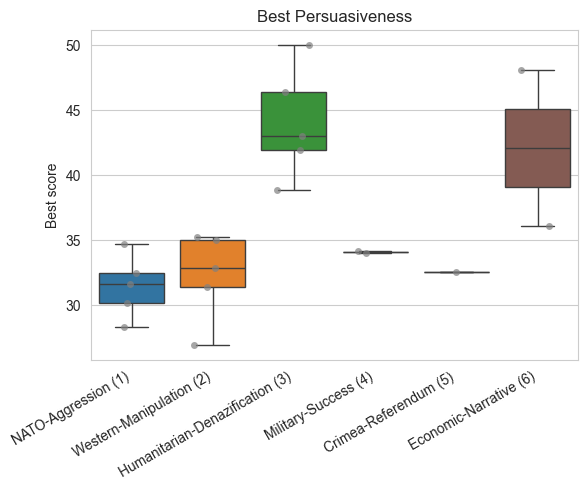

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":       ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":  ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)":          ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":      ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)":    ["claim7", "claim18"],
}

agent       = "CN_Creator_Agent_1"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_pers"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim in claim_list:
        fp = Path(file_pattern.format(claim=claim, agent=agent))
        df = pd.read_csv(fp, usecols=[AVG_COL])
        best_rows.append(
            {"group": group_name,
             "claim": claim,
             "best_score": df[AVG_COL].max()}
        )

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    x="group", y="best_score", data=best_df,
    ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
)
sns.stripplot(
    x="group", y="best_score", data=best_df,
    ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
)

ax.set_title("Best Persuasiveness")
ax.set_xlabel("")
ax.set_ylabel("Best score")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()

# Save the plot
output_dir = Path("group_analysis_results/scores_per_group/only_highest")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "best_persuasiveness.png", dpi=300, bbox_inches="tight")

plt.show()

#### Option 1: ANOVA + Tukey

In [13]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

              sum_sq    df         F    PR(>F)
C(group)  587.057253   5.0  7.680237  0.001161
Residual  214.024691  14.0       NaN       NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)      9.5 0.3971  -6.2065 25.2065  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)  11.4444 0.1433  -2.6039 25.4928  False
          Crimea-Referendum (5)            Military-Success (4)      1.5 0.9995 -14.2065 17.2065  False
          Crimea-Referendum (5)             NATO-Aggression (1)  -1.1222 0.9998 -15.1706 12.9261  False
          Crimea-Referendum (5)        Western-Manipulation (2)  -0.3111    1.0 -14.3594 13.7372  F

#### Option 2: Kruskal-Wallis + Dunn

In [14]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best persuasiveness ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best persuasiveness ===
H = 13.794,  p = 0.01697

Pairwise Dunn (Holm-corrected p-values):
Humanitarian-Denazification (3)  vs  NATO-Aggression (1)   →   p = 0.0242


### KPI 2 - Emotional Engagement

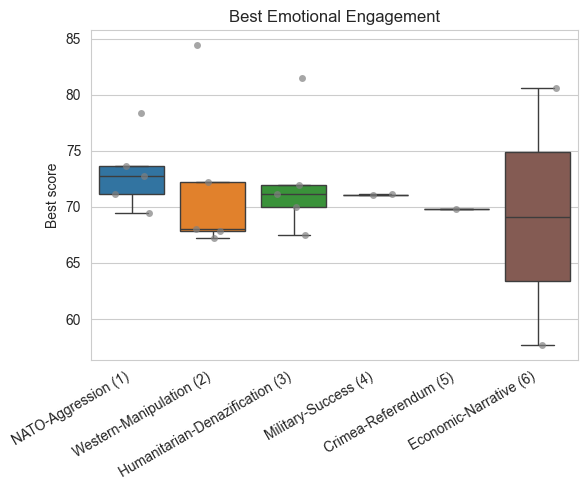

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":       ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":  ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)":          ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":      ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)":    ["claim7", "claim18"],
}

agent       = "CN_Creator_Agent_2"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_emot"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim in claim_list:
        fp = Path(file_pattern.format(claim=claim, agent=agent))
        df = pd.read_csv(fp, usecols=[AVG_COL])
        best_rows.append(
            {"group": group_name,
             "claim": claim,
             "best_score": df[AVG_COL].max()}
        )

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    x="group", y="best_score", data=best_df,
    ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
)
sns.stripplot(
    x="group", y="best_score", data=best_df,
    ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
)

ax.set_title("Best Emotional Engagement")
ax.set_xlabel("")
ax.set_ylabel("Best score")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()

# Save the plot
output_dir = Path("group_analysis_results/scores_per_group/only_highest")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "best_emot.png", dpi=300, bbox_inches="tight")

plt.show()

#### Option 1: ANOVA + Tukey

In [16]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

              sum_sq    df         F    PR(>F)
C(group)   29.379012   5.0  0.130055  0.982919
Residual  632.510494  14.0       NaN       NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)  -0.6389    1.0   -27.64 26.3622  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)   2.6444  0.999 -21.5061  26.795  False
          Crimea-Referendum (5)            Military-Success (4)   1.3056    1.0 -25.6956 28.3067  False
          Crimea-Referendum (5)             NATO-Aggression (1)      3.3 0.9972 -20.8505 27.4505  False
          Crimea-Referendum (5)        Western-Manipulation (2)   2.1667 0.9996 -21.9839 26.3172  F

#### Option 2: Kruskal-Wallis + Dunn

In [17]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best emotional engagement ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best emotional engagement ===
H = 1.621,  p = 0.8988

Pairwise Dunn (Holm-corrected p-values):
No pairwise differences survive Holm correction.


### KPI 3 - Shareability

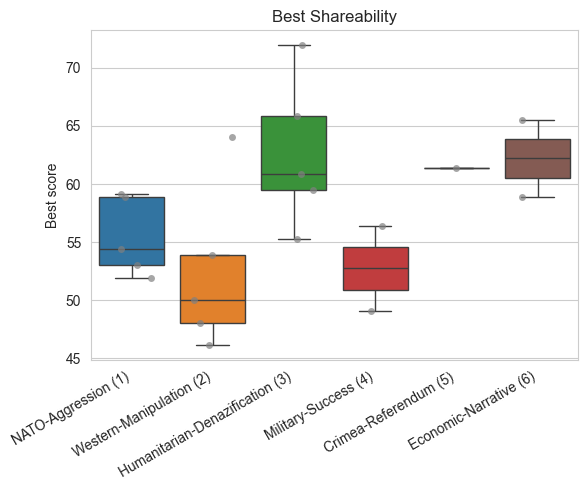

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":       ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":  ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)":          ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":      ["claim5", "claim17"],
    "Crimea-Referendum (5)": ["claim8"],
    "Economic-Narrative (6)":    ["claim7", "claim18"],
}

agent       = "CN_Creator_Agent_3"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_share"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim in claim_list:
        fp = Path(file_pattern.format(claim=claim, agent=agent))
        df = pd.read_csv(fp, usecols=[AVG_COL])
        best_rows.append(
            {"group": group_name,
             "claim": claim,
             "best_score": df[AVG_COL].max()}
        )

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    x="group", y="best_score", data=best_df,
    ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
)
sns.stripplot(
    x="group", y="best_score", data=best_df,
    ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
)

ax.set_title("Best Shareability")
ax.set_xlabel("")
ax.set_ylabel("Best score")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()

# Save the plot
output_dir = Path("group_analysis_results/scores_per_group/only_highest")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "best_share.png", dpi=300, bbox_inches="tight")

plt.show()

#### Option 1: ANOVA + Tukey

In [19]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

              sum_sq    df         F    PR(>F)
C(group)  386.098765   5.0  2.347785  0.095603
Residual  460.466667  14.0       NaN       NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)   0.8333    1.0 -22.2048 23.8714  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)   1.2778 0.9999 -19.3281 21.8837  False
          Crimea-Referendum (5)            Military-Success (4)  -8.6667 0.8137 -31.7048 14.3714  False
          Crimea-Referendum (5)             NATO-Aggression (1)  -5.8889 0.9299 -26.4948  14.717  False
          Crimea-Referendum (5)        Western-Manipulation (2)  -8.9667 0.7114 -29.5726 11.6392  F

#### Option 2: Kruskal-Wallis + Dunn

In [20]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best shareability ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best shareability ===
H = 9.352,  p = 0.09582

Pairwise Dunn (Holm-corrected p-values):
No pairwise differences survive Holm correction.


## **(b) 5 Highest Scores From Each Claim as Data Points**

### KPI 1 - Persuasiveness

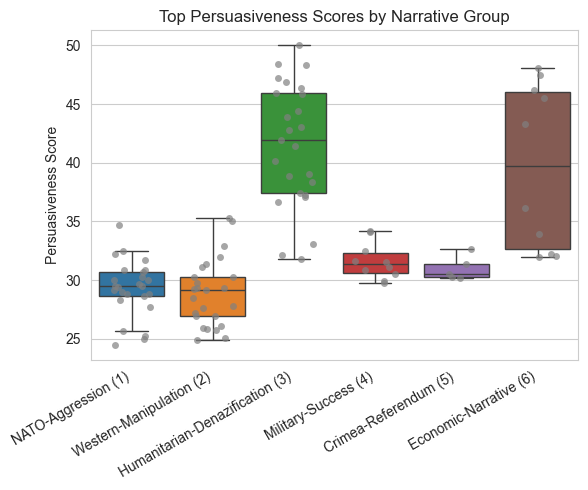

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats # These imports were in your original full script
from statsmodels.stats.multicomp import pairwise_tukeyhsd # but not strictly needed
import statsmodels.formula.api as smf # for the snippet provided.
import statsmodels.api as sm # I'll keep them as they might be
import scikit_posthocs as sp # used elsewhere in your full context.

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_1"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv" # Raw string is fine

AVG_COL = "avg_pers"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list: # Using 'claim_id' for the loop variable for clarity
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            # Attempt to read the CSV, loading only the required column
            # This will raise FileNotFoundError if fp doesn't exist.
            # It will raise ValueError if AVG_COL is not in the CSV's columns.
            # It will raise pd.errors.EmptyDataError if the file is empty.
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Get the 5 largest scores for the current claim.
            # .nlargest(5) will return fewer than 5 if fewer are available.
            # It will return an empty Series if df[AVG_COL] is empty or all NaNs.
            # It will raise TypeError if data in AVG_COL is not numeric.
            top_scores = df[AVG_COL].nlargest(5)

            for score in top_scores: # If top_scores is empty, this loop won't run
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,       # Storing the original claim identifier
                     "best_score": score}     # One of the top N scores
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError: # Covers AVG_COL not in CSV columns specified by usecols
            print(f"INFO: Column '{AVG_COL}' not found or other ValueError for claim '{claim_id}' in {fp}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except TypeError: # Covers nlargest() on non-numeric data (e.g., if AVG_COL was read as object type)
            print(f"INFO: Data in '{AVG_COL}' for claim '{claim_id}' in {fp} is not numeric. Skipping.")
        except Exception as e: # Catch any other unexpected errors during file processing
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty: # Proceed to plot only if data was successfully loaded
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.boxplot(
        x="group", y="best_score", data=best_df,
        ax=ax, hue="group", whis=1.5, fliersize=0, legend=False # legend=False as group is on x-axis
    )
    sns.stripplot(
        x="group", y="best_score", data=best_df,
        ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
    )

    ax.set_title("Top Persuasiveness Scores by Narrative Group") # Title slightly adjusted for context
    ax.set_xlabel("") # X-axis label is clear from ticks
    ax.set_ylabel("Persuasiveness Score") # Y-axis label adjusted
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right") # Ensure rotated labels are aligned well

    plt.tight_layout()

        # Save the plot
    output_dir = Path("group_analysis_results/scores_per_group/five_highest")
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "best_persuasiveness.png", dpi=300, bbox_inches="tight")

    plt.show()
else:
    print("No data was loaded into the DataFrame. Plot cannot be generated.")

#### Option 1: ANOVA + Tukey

In [22]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

               sum_sq    df          F        PR(>F)
C(group)  3024.421451   5.0  38.635057  2.259361e-21
Residual  1471.697654  94.0        NaN           NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)   8.6833 0.0017   2.3781 14.9886   True
          Crimea-Referendum (5) Humanitarian-Denazification (3)  10.5378    0.0   4.8982 16.1774   True
          Crimea-Referendum (5)            Military-Success (4)   0.6056 0.9998  -5.6997  6.9108  False
          Crimea-Referendum (5)             NATO-Aggression (1)  -1.7022 0.9508  -7.3418  3.9374  False
          Crimea-Referendum (5)        Western-Manipulation (2)    -2.06 0.8948  

#### Option 2: Kruskal-Wallis + Dunn

In [23]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best persuasiveness ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best persuasiveness ===
H = 66.502,  p = 5.466e-13

Pairwise Dunn (Holm-corrected p-values):
Humanitarian-Denazification (3)  vs  Western-Manipulation (2)   →   p = 3.93e-10
Humanitarian-Denazification (3)  vs  NATO-Aggression (1)   →   p = 2.66e-09
Economic-Narrative (6)  vs  Western-Manipulation (2)   →   p = 6.82e-05
Economic-Narrative (6)  vs  NATO-Aggression (1)   →   p = 0.000179
Humanitarian-Denazification (3)  vs  Military-Success (4)   →   p = 0.0356


### KPI 2 - Emotional Engagement

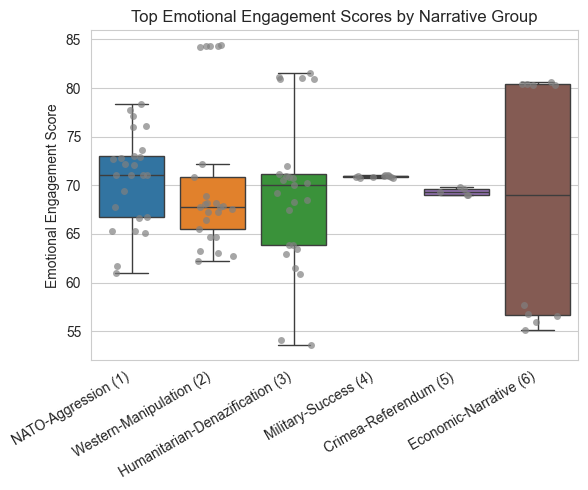

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats # These imports were in your original full script
from statsmodels.stats.multicomp import pairwise_tukeyhsd # but not strictly needed
import statsmodels.formula.api as smf # for the snippet provided.
import statsmodels.api as sm # I'll keep them as they might be
import scikit_posthocs as sp # used elsewhere in your full context.

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_2"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv" # Raw string is fine

AVG_COL = "avg_emot"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list: # Using 'claim_id' for the loop variable for clarity
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            # Attempt to read the CSV, loading only the required column
            # This will raise FileNotFoundError if fp doesn't exist.
            # It will raise ValueError if AVG_COL is not in the CSV's columns.
            # It will raise pd.errors.EmptyDataError if the file is empty.
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Get the 5 largest scores for the current claim.
            # .nlargest(5) will return fewer than 5 if fewer are available.
            # It will return an empty Series if df[AVG_COL] is empty or all NaNs.
            # It will raise TypeError if data in AVG_COL is not numeric.
            top_scores = df[AVG_COL].nlargest(5)

            for score in top_scores: # If top_scores is empty, this loop won't run
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,       # Storing the original claim identifier
                     "best_score": score}     # One of the top N scores
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError: # Covers AVG_COL not in CSV columns specified by usecols
            print(f"INFO: Column '{AVG_COL}' not found or other ValueError for claim '{claim_id}' in {fp}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except TypeError: # Covers nlargest() on non-numeric data (e.g., if AVG_COL was read as object type)
            print(f"INFO: Data in '{AVG_COL}' for claim '{claim_id}' in {fp} is not numeric. Skipping.")
        except Exception as e: # Catch any other unexpected errors during file processing
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty: # Proceed to plot only if data was successfully loaded
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.boxplot(
        x="group", y="best_score", data=best_df,
        ax=ax, hue="group", whis=1.5, fliersize=0, legend=False # legend=False as group is on x-axis
    )
    sns.stripplot(
        x="group", y="best_score", data=best_df,
        ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
    )

    ax.set_title("Top Emotional Engagement Scores by Narrative Group") # Title slightly adjusted for context
    ax.set_xlabel("") # X-axis label is clear from ticks
    ax.set_ylabel("Emotional Engagement Score") # Y-axis label adjusted
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right") # Ensure rotated labels are aligned well

    plt.tight_layout()

        # Save the plot
    output_dir = Path("group_analysis_results/scores_per_group/five_highest")
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "best_emot.png", dpi=300, bbox_inches="tight")

    plt.show()
else:
    print("No data was loaded into the DataFrame. Plot cannot be generated.")

#### Option 1: ANOVA + Tukey

In [25]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

           sum_sq    df         F    PR(>F)
C(group)    65.74   5.0  0.256028  0.935789
Residual  4827.25  94.0       NaN       NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)  -0.9278 0.9999 -12.3471 10.4916  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)  -0.1756    1.0 -10.3893 10.0382  False
          Crimea-Referendum (5)            Military-Success (4)   1.5611 0.9987  -9.8583 12.9805  False
          Crimea-Referendum (5)             NATO-Aggression (1)     1.36 0.9988  -8.8538 11.5738  False
          Crimea-Referendum (5)        Western-Manipulation (2)   0.8778 0.9999   -9.336 11.0916  False
    

#### Option 2: Kruskal-Wallis + Dunn

In [26]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best emotional engagement ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best emotional engagement ===
H = 4.456,  p = 0.4858

Pairwise Dunn (Holm-corrected p-values):
No pairwise differences survive Holm correction.


### KPI 3 - Shareability

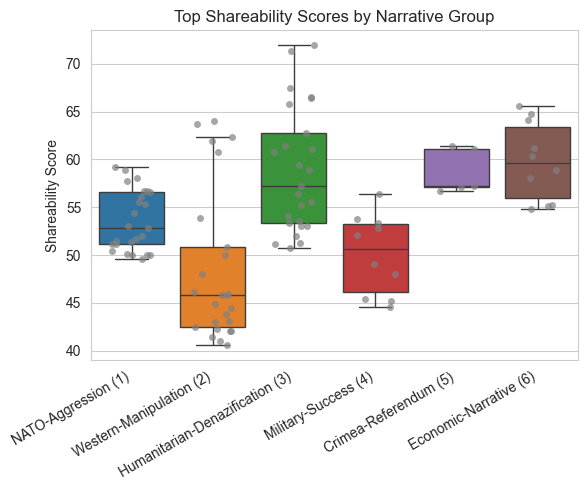

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats # These imports were in your original full script
from statsmodels.stats.multicomp import pairwise_tukeyhsd # but not strictly needed
import statsmodels.formula.api as smf # for the snippet provided.
import statsmodels.api as sm # I'll keep them as they might be
import scikit_posthocs as sp # used elsewhere in your full context.

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_3"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv" # Raw string is fine

AVG_COL = "avg_share"   # persuasiveness column in each CSV
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list: # Using 'claim_id' for the loop variable for clarity
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            # Attempt to read the CSV, loading only the required column
            # This will raise FileNotFoundError if fp doesn't exist.
            # It will raise ValueError if AVG_COL is not in the CSV's columns.
            # It will raise pd.errors.EmptyDataError if the file is empty.
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Get the 5 largest scores for the current claim.
            # .nlargest(5) will return fewer than 5 if fewer are available.
            # It will return an empty Series if df[AVG_COL] is empty or all NaNs.
            # It will raise TypeError if data in AVG_COL is not numeric.
            top_scores = df[AVG_COL].nlargest(5)

            for score in top_scores: # If top_scores is empty, this loop won't run
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,       # Storing the original claim identifier
                     "best_score": score}     # One of the top N scores
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError: # Covers AVG_COL not in CSV columns specified by usecols
            print(f"INFO: Column '{AVG_COL}' not found or other ValueError for claim '{claim_id}' in {fp}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except TypeError: # Covers nlargest() on non-numeric data (e.g., if AVG_COL was read as object type)
            print(f"INFO: Data in '{AVG_COL}' for claim '{claim_id}' in {fp} is not numeric. Skipping.")
        except Exception as e: # Catch any other unexpected errors during file processing
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty: # Proceed to plot only if data was successfully loaded
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.boxplot(
        x="group", y="best_score", data=best_df,
        ax=ax, hue="group", whis=1.5, fliersize=0, legend=False # legend=False as group is on x-axis
    )
    sns.stripplot(
        x="group", y="best_score", data=best_df,
        ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
    )

    ax.set_title("Top Shareability Scores by Narrative Group") # Title slightly adjusted for context
    ax.set_xlabel("") # X-axis label is clear from ticks
    ax.set_ylabel("Shareability Score") # Y-axis label adjusted
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right") # Ensure rotated labels are aligned well

    plt.tight_layout()

        # Save the plot
    output_dir = Path("group_analysis_results/scores_per_group/five_highest")
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "best_share.png", dpi=300, bbox_inches="tight")

    plt.show()
else:
    print("No data was loaded into the DataFrame. Plot cannot be generated.")

#### Option 1: ANOVA + Tukey

In [28]:
model = smf.ols('best_score ~ C(group)', data=best_df).fit()
p = model.f_pvalue
print(sm.stats.anova_lm(model, typ=2))

# Tukey HSD (post-hoc) if overall p < 0.05
print("\nPairwise Tukey HSD (α = 0.05):")
tukey = pairwise_tukeyhsd(best_df["best_score"],
                            best_df["group"],
                            alpha=0.05)
print(tukey)

               sum_sq    df          F        PR(>F)
C(group)  1967.618056   5.0  11.996378  5.425509e-09
Residual  3083.532407  94.0        NaN           NaN

Pairwise Tukey HSD (α = 0.05):
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)   1.1111 0.9992  -8.0156 10.2379  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)   0.1244    1.0  -8.0388  8.2877  False
          Crimea-Referendum (5)            Military-Success (4)  -8.6278  0.075 -17.7545   0.499  False
          Crimea-Referendum (5)             NATO-Aggression (1)  -5.1067 0.4581 -13.2699  3.0566  False
          Crimea-Referendum (5)        Western-Manipulation (2) -10.2889 0.0053 -

#### Option 2: Kruskal-Wallis + Dunn

In [29]:
samples = [best_df.loc[best_df.group == g, "best_score"]
           for g in best_df["group"].unique()]

H, p_kw = stats.kruskal(*samples)
print(f"\n=== Kruskal–Wallis on best shareability ===")
print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

# Dunn test with Holm FWER correction if global test is significant
print("\nPairwise Dunn (Holm-corrected p-values):")
dunn = sp.posthoc_dunn(best_df, val_col="best_score",
                        group_col="group",
                        p_adjust="holm")    # other options: 'bonferroni', 'fdr_bh', …

alpha = 0.05

mask = np.triu(np.ones(dunn.shape, dtype=bool), k=1) # k=1 to exclude the diagonal

sig_pairs = (
    dunn.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
        .query("p_value < @alpha")
        .sort_values("p_value")
)

if sig_pairs.empty:
    print("No pairwise differences survive Holm correction.")
else:
    for _, row in sig_pairs.iterrows():
        g1, g2, p = row.tolist()
        print(f"{g1}  vs  {g2}   →   p = {p:.3g}")


=== Kruskal–Wallis on best shareability ===
H = 38.283,  p = 3.31e-07

Pairwise Dunn (Holm-corrected p-values):
Humanitarian-Denazification (3)  vs  Western-Manipulation (2)   →   p = 2.27e-05
Economic-Narrative (6)  vs  Western-Manipulation (2)   →   p = 0.000217
Economic-Narrative (6)  vs  Military-Success (4)   →   p = 0.0128
Humanitarian-Denazification (3)  vs  Military-Success (4)   →   p = 0.0137
Crimea-Referendum (5)  vs  Western-Manipulation (2)   →   p = 0.0138


## **(c) All Scores From Each Claim as Data Points**

### KPI 1 - Persuasiveness

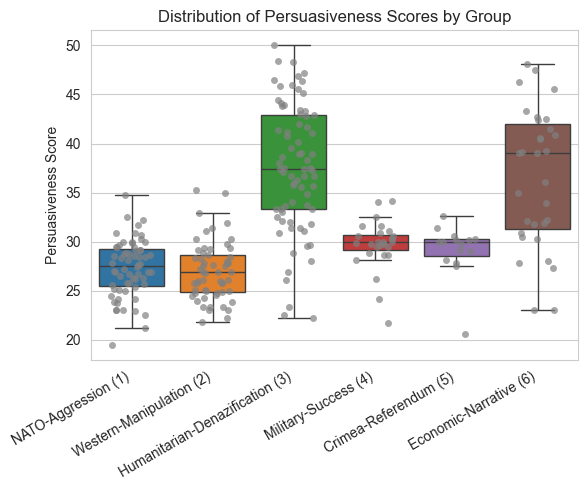


--- ANOVA Test ---
               sum_sq     df          F        PR(>F)
C(group)  5893.913161    5.0  52.930299  8.596828e-38
Residual  5812.592618  261.0        NaN           NaN

--- Pairwise Tukey HSD (α = 0.05) ---
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)   7.3792    0.0   3.1178 11.6406   True
          Crimea-Referendum (5) Humanitarian-Denazification (3)   8.4123    0.0   4.5714 12.2532   True
          Crimea-Referendum (5)            Military-Success (4)   0.5601 0.9991   -3.803  4.9232  False
          Crimea-Referendum (5)             NATO-Aggression (1)  -1.8269 0.7569  -5.7136  2.0598  False
          Crimea-Referendum (5)        Western-Mani

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp
import numpy as np # Required for the Dunn test part

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_1"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_pers"   # persuasiveness column in each CSV
SCORE_COL_DF = "score_value" # New name for the score column in best_df
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Ensure the score column is numeric, coercing errors to NaN
            df[AVG_COL] = pd.to_numeric(df[AVG_COL], errors='coerce')
            
            # You can choose to drop NaNs here if they are not meaningful for your analysis
            # For example: df.dropna(subset=[AVG_COL], inplace=True)
            # For now, we'll keep NaNs, as many statistical functions can handle them.

            all_scores_from_claim = df[AVG_COL]

            if all_scores_from_claim.empty:
                # This might happen if the column was empty or all values became NaN after coercion (and if you then used dropna)
                print(f"INFO: No valid scores found in '{AVG_COL}' for claim '{claim_id}' in {fp} after processing. Skipping.")
                continue

            for score in all_scores_from_claim:
                # 'score' will be a float (numeric) or NaN
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,
                     SCORE_COL_DF: score} # Using the new column name
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError as e: # Covers AVG_COL not in CSV by usecols, or other pd.read_csv value errors
            print(f"INFO: ValueError for claim '{claim_id}' in {fp} (e.g., column '{AVG_COL}' not found, or CSV format issue). Error: {e}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except Exception as e: # Catch any other unexpected errors
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty:
    # Drop rows where the score is NaN for plotting and most stats, if not already handled
    # best_df_cleaned = best_df.dropna(subset=[SCORE_COL_DF])
    # For simplicity, many functions below will handle NaNs or you might prefer to keep them if appropriate
    best_df_cleaned = best_df 
    if best_df_cleaned.empty :
        print("No valid data after attempting to clean NaNs. Plot and stats cannot be generated.")
    else:
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(figsize=(6, 5))

        sns.boxplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
        )
        sns.stripplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
        )

        ax.set_title("Distribution of Persuasiveness Scores by Group") # Adjusted title
        ax.set_xlabel("")
        ax.set_ylabel("Persuasiveness Score")
        ax.tick_params(axis="x", rotation=30)
        plt.setp(ax.get_xticklabels(), ha="right")

        plt.tight_layout()
        # Save the plot
        output_dir = Path("group_analysis_results/scores_per_group/all_points")
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / "best_persuasiveness.png", dpi=300, bbox_inches="tight")
        plt.show()

        # ---------- STATISTICAL ANALYSIS ----------
        # Ensure there's enough data for statistical tests
        if best_df_cleaned[SCORE_COL_DF].notna().sum() > 0 and best_df_cleaned['group'].nunique() > 1:
            print("\n--- ANOVA Test ---")
            model = smf.ols(f'{SCORE_COL_DF} ~ C(group)', data=best_df_cleaned).fit() # Use new score column name
            # p_anova = model.f_pvalue # This would be for the overall model
            anova_table = sm.stats.anova_lm(model, typ=2)
            print(anova_table)
            overall_p_value_anova = anova_table["PR(>F)"].iloc[0]


            if overall_p_value_anova < 0.05:
                print("\n--- Pairwise Tukey HSD (α = 0.05) ---")
                tukey = pairwise_tukeyhsd(best_df_cleaned[SCORE_COL_DF], # Use new score column name
                                          best_df_cleaned["group"],
                                          alpha=0.05)
                print(tukey)
            else:
                print("\nOverall ANOVA p-value >= 0.05, Tukey HSD not performed.")

            print("\n--- Kruskal–Wallis Test ---")
            # Kruskal-Wallis requires list of samples; dropna within list comprehension for safety
            samples = [group_data[SCORE_COL_DF].dropna().values for name, group_data in best_df_cleaned.groupby("group")]
            # Filter out empty arrays from samples if a group had all NaNs
            samples = [s for s in samples if len(s) > 0]
            
            if len(samples) > 1: # Need at least two groups to compare
                H, p_kw = stats.kruskal(*samples)
                print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

                if p_kw < 0.05:
                    print("\n--- Pairwise Dunn Test (Holm-corrected p-values) ---")
                    # Ensure no NaNs are passed to posthoc_dunn for the value column
                    dunn_df_cleaned = best_df_cleaned.dropna(subset=[SCORE_COL_DF])
                    if not dunn_df_cleaned.empty and dunn_df_cleaned['group'].nunique() > 1:
                        dunn_results = sp.posthoc_dunn(dunn_df_cleaned, val_col=SCORE_COL_DF, # Use new score column name
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha = 0.05
                        mask = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)

                        sig_pairs = (
                            dunn_results.where(mask)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha")
                                .sort_values("p_value")
                        )

                        if sig_pairs.empty:
                            print("No pairwise differences survive Holm correction.")
                        else:
                            for _, row in sig_pairs.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"{g1}  vs  {g2}   →   p = {p_val:.3g}")
                    else:
                        print("Not enough data for Dunn's test after NaN removal or too few groups.")
                else:
                    print("\nOverall Kruskal-Wallis p-value >= 0.05, Dunn's test not performed.")
            else:
                print("Not enough groups with valid data for Kruskal-Wallis test.")
        else:
            print("Not enough valid data or groups to perform statistical tests.")
else:
    print("No data was loaded into the DataFrame. Plot and statistical analysis cannot be performed.")

### KPI 2 - Emotional Engagement

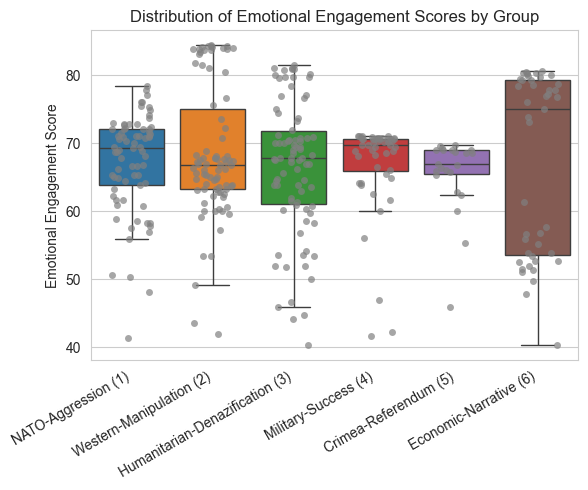


--- ANOVA Test ---
                sum_sq     df         F    PR(>F)
C(group)    252.193502    5.0  0.583225  0.712863
Residual  29749.963685  344.0       NaN       NaN

Overall ANOVA p-value >= 0.05, Tukey HSD not performed.

--- Kruskal–Wallis Test ---
H = 2.946,  p = 0.7083

Overall Kruskal-Wallis p-value >= 0.05, Dunn's test not performed.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp
import numpy as np # Required for the Dunn test part

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_2"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_emot"
SCORE_COL_DF = "score_value" # New name for the score column in best_df
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Ensure the score column is numeric, coercing errors to NaN
            df[AVG_COL] = pd.to_numeric(df[AVG_COL], errors='coerce')
            
            # You can choose to drop NaNs here if they are not meaningful for your analysis
            # For example: df.dropna(subset=[AVG_COL], inplace=True)
            # For now, we'll keep NaNs, as many statistical functions can handle them.

            all_scores_from_claim = df[AVG_COL]

            if all_scores_from_claim.empty:
                # This might happen if the column was empty or all values became NaN after coercion (and if you then used dropna)
                print(f"INFO: No valid scores found in '{AVG_COL}' for claim '{claim_id}' in {fp} after processing. Skipping.")
                continue

            for score in all_scores_from_claim:
                # 'score' will be a float (numeric) or NaN
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,
                     SCORE_COL_DF: score} # Using the new column name
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError as e: # Covers AVG_COL not in CSV by usecols, or other pd.read_csv value errors
            print(f"INFO: ValueError for claim '{claim_id}' in {fp} (e.g., column '{AVG_COL}' not found, or CSV format issue). Error: {e}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except Exception as e: # Catch any other unexpected errors
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty:
    # Drop rows where the score is NaN for plotting and most stats, if not already handled
    # best_df_cleaned = best_df.dropna(subset=[SCORE_COL_DF])
    # For simplicity, many functions below will handle NaNs or you might prefer to keep them if appropriate
    best_df_cleaned = best_df 
    if best_df_cleaned.empty :
        print("No valid data after attempting to clean NaNs. Plot and stats cannot be generated.")
    else:
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(figsize=(6, 5))

        sns.boxplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
        )
        sns.stripplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
        )

        ax.set_title("Distribution of Emotional Engagement Scores by Group") # Adjusted title
        ax.set_xlabel("")
        ax.set_ylabel("Emotional Engagement Score")
        ax.tick_params(axis="x", rotation=30)
        plt.setp(ax.get_xticklabels(), ha="right")

        plt.tight_layout()
        # Save the plot
        output_dir = Path("group_analysis_results/scores_per_group/all_points")
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / "best_emot.png", dpi=300, bbox_inches="tight")
        plt.show()

        # ---------- STATISTICAL ANALYSIS ----------
        # Ensure there's enough data for statistical tests
        if best_df_cleaned[SCORE_COL_DF].notna().sum() > 0 and best_df_cleaned['group'].nunique() > 1:
            print("\n--- ANOVA Test ---")
            model = smf.ols(f'{SCORE_COL_DF} ~ C(group)', data=best_df_cleaned).fit() # Use new score column name
            # p_anova = model.f_pvalue # This would be for the overall model
            anova_table = sm.stats.anova_lm(model, typ=2)
            print(anova_table)
            overall_p_value_anova = anova_table["PR(>F)"].iloc[0]


            if overall_p_value_anova < 0.05:
                print("\n--- Pairwise Tukey HSD (α = 0.05) ---")
                tukey = pairwise_tukeyhsd(best_df_cleaned[SCORE_COL_DF], # Use new score column name
                                          best_df_cleaned["group"],
                                          alpha=0.05)
                print(tukey)
            else:
                print("\nOverall ANOVA p-value >= 0.05, Tukey HSD not performed.")

            print("\n--- Kruskal–Wallis Test ---")
            # Kruskal-Wallis requires list of samples; dropna within list comprehension for safety
            samples = [group_data[SCORE_COL_DF].dropna().values for name, group_data in best_df_cleaned.groupby("group")]
            # Filter out empty arrays from samples if a group had all NaNs
            samples = [s for s in samples if len(s) > 0]
            
            if len(samples) > 1: # Need at least two groups to compare
                H, p_kw = stats.kruskal(*samples)
                print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

                if p_kw < 0.05:
                    print("\n--- Pairwise Dunn Test (Holm-corrected p-values) ---")
                    # Ensure no NaNs are passed to posthoc_dunn for the value column
                    dunn_df_cleaned = best_df_cleaned.dropna(subset=[SCORE_COL_DF])
                    if not dunn_df_cleaned.empty and dunn_df_cleaned['group'].nunique() > 1:
                        dunn_results = sp.posthoc_dunn(dunn_df_cleaned, val_col=SCORE_COL_DF, # Use new score column name
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha = 0.05
                        mask = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)

                        sig_pairs = (
                            dunn_results.where(mask)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha")
                                .sort_values("p_value")
                        )

                        if sig_pairs.empty:
                            print("No pairwise differences survive Holm correction.")
                        else:
                            for _, row in sig_pairs.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"{g1}  vs  {g2}   →   p = {p_val:.3g}")
                    else:
                        print("Not enough data for Dunn's test after NaN removal or too few groups.")
                else:
                    print("\nOverall Kruskal-Wallis p-value >= 0.05, Dunn's test not performed.")
            else:
                print("Not enough groups with valid data for Kruskal-Wallis test.")
        else:
            print("Not enough valid data or groups to perform statistical tests.")
else:
    print("No data was loaded into the DataFrame. Plot and statistical analysis cannot be performed.")

### KPI 3 - Shareability

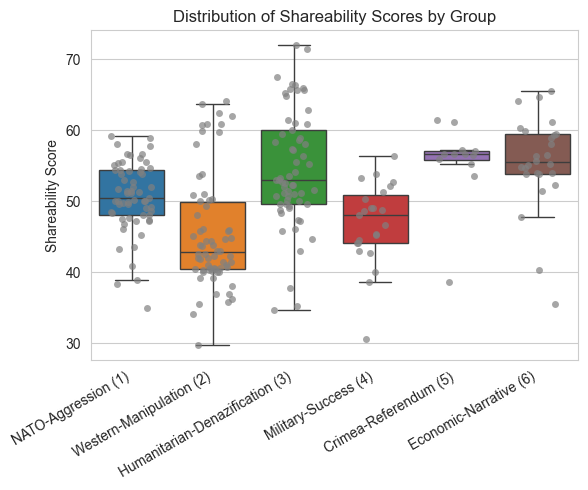


--- ANOVA Test ---
                sum_sq     df         F        PR(>F)
C(group)   3957.178047    5.0  16.17366  9.189308e-14
Residual  11890.867493  243.0       NaN           NaN

--- Pairwise Tukey HSD (α = 0.05) ---
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------------------
          Crimea-Referendum (5)          Economic-Narrative (6)   -0.062    1.0  -7.0748  6.9509  False
          Crimea-Referendum (5) Humanitarian-Denazification (3)  -0.9444 0.9982  -7.2902  5.4013  False
          Crimea-Referendum (5)            Military-Success (4)  -8.6546 0.0079 -15.8104 -1.4988   True
          Crimea-Referendum (5)             NATO-Aggression (1)   -4.939 0.2253 -11.2848  1.4068  False
          Crimea-Referendum (5)        Western-Mani

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scikit_posthocs as sp
import numpy as np # Required for the Dunn test part

# ---------- CONFIG ----------
groups = {
    "NATO-Aggression (1)":         ["claim1", "claim3", "claim15", "claim4", "claim20"],
    "Western-Manipulation (2)":    ["claim11", "claim12", "claim13", "claim14", "claim9"],
    "Humanitarian-Denazification (3)": ["claim2", "claim6", "claim16", "claim10", "claim19"],
    "Military-Success (4)":        ["claim5", "claim17"],
    "Crimea-Referendum (5)":       ["claim8"],
    "Economic-Narrative (6)":      ["claim7", "claim18"],
}

agent        = "CN_Creator_Agent_3"
file_pattern = r"refinement_per_claim_final_results/{claim}/{agent}.csv"

AVG_COL = "avg_share"
SCORE_COL_DF = "score_value" # New name for the score column in best_df
# ----------------------------

best_rows = []
for group_name, claim_list in groups.items():
    for claim_id in claim_list:
        fp = Path(file_pattern.format(claim=claim_id, agent=agent))
        try:
            df = pd.read_csv(fp, usecols=[AVG_COL])
            
            # Ensure the score column is numeric, coercing errors to NaN
            df[AVG_COL] = pd.to_numeric(df[AVG_COL], errors='coerce')
            
            # You can choose to drop NaNs here if they are not meaningful for your analysis
            # For example: df.dropna(subset=[AVG_COL], inplace=True)
            # For now, we'll keep NaNs, as many statistical functions can handle them.

            all_scores_from_claim = df[AVG_COL]

            if all_scores_from_claim.empty:
                # This might happen if the column was empty or all values became NaN after coercion (and if you then used dropna)
                print(f"INFO: No valid scores found in '{AVG_COL}' for claim '{claim_id}' in {fp} after processing. Skipping.")
                continue

            for score in all_scores_from_claim:
                # 'score' will be a float (numeric) or NaN
                best_rows.append(
                    {"group": group_name,
                     "claim": claim_id,
                     SCORE_COL_DF: score} # Using the new column name
                )
        except FileNotFoundError:
            print(f"INFO: File not found for claim '{claim_id}' at {fp}. Skipping.")
        except ValueError as e: # Covers AVG_COL not in CSV by usecols, or other pd.read_csv value errors
            print(f"INFO: ValueError for claim '{claim_id}' in {fp} (e.g., column '{AVG_COL}' not found, or CSV format issue). Error: {e}. Skipping.")
        except pd.errors.EmptyDataError:
             print(f"INFO: File for claim '{claim_id}' at {fp} is empty. Skipping.")
        except Exception as e: # Catch any other unexpected errors
            print(f"ERROR: An unexpected error occurred processing claim '{claim_id}' from {fp}. Details: {e}. Skipping.")

best_df = pd.DataFrame(best_rows)

# ---------- PLOT ----------
if not best_df.empty:
    # Drop rows where the score is NaN for plotting and most stats, if not already handled
    # best_df_cleaned = best_df.dropna(subset=[SCORE_COL_DF])
    # For simplicity, many functions below will handle NaNs or you might prefer to keep them if appropriate
    best_df_cleaned = best_df 
    if best_df_cleaned.empty :
        print("No valid data after attempting to clean NaNs. Plot and stats cannot be generated.")
    else:
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(figsize=(6, 5))

        sns.boxplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, hue="group", whis=1.5, fliersize=0, legend=False
        )
        sns.stripplot(
            x="group", y=SCORE_COL_DF, data=best_df_cleaned, # Use new score column name
            ax=ax, size=5, jitter=0.25, color="grey", alpha=0.7
        )

        ax.set_title("Distribution of Shareability Scores by Group") # Adjusted title
        ax.set_xlabel("")
        ax.set_ylabel("Shareability Score")
        ax.tick_params(axis="x", rotation=30)
        plt.setp(ax.get_xticklabels(), ha="right")

        plt.tight_layout()
        # Save the plot
        output_dir = Path("group_analysis_results/scores_per_group/all_points")
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / "best_share.png", dpi=300, bbox_inches="tight")
        plt.show()

        # ---------- STATISTICAL ANALYSIS ----------
        # Ensure there's enough data for statistical tests
        if best_df_cleaned[SCORE_COL_DF].notna().sum() > 0 and best_df_cleaned['group'].nunique() > 1:
            print("\n--- ANOVA Test ---")
            model = smf.ols(f'{SCORE_COL_DF} ~ C(group)', data=best_df_cleaned).fit() # Use new score column name
            # p_anova = model.f_pvalue # This would be for the overall model
            anova_table = sm.stats.anova_lm(model, typ=2)
            print(anova_table)
            overall_p_value_anova = anova_table["PR(>F)"].iloc[0]


            if overall_p_value_anova < 0.05:
                print("\n--- Pairwise Tukey HSD (α = 0.05) ---")
                tukey = pairwise_tukeyhsd(best_df_cleaned[SCORE_COL_DF], # Use new score column name
                                          best_df_cleaned["group"],
                                          alpha=0.05)
                print(tukey)
            else:
                print("\nOverall ANOVA p-value >= 0.05, Tukey HSD not performed.")

            print("\n--- Kruskal–Wallis Test ---")
            # Kruskal-Wallis requires list of samples; dropna within list comprehension for safety
            samples = [group_data[SCORE_COL_DF].dropna().values for name, group_data in best_df_cleaned.groupby("group")]
            # Filter out empty arrays from samples if a group had all NaNs
            samples = [s for s in samples if len(s) > 0]
            
            if len(samples) > 1: # Need at least two groups to compare
                H, p_kw = stats.kruskal(*samples)
                print(f"H = {H:0.3f},  p = {p_kw:0.4g}")

                if p_kw < 0.05:
                    print("\n--- Pairwise Dunn Test (Holm-corrected p-values) ---")
                    # Ensure no NaNs are passed to posthoc_dunn for the value column
                    dunn_df_cleaned = best_df_cleaned.dropna(subset=[SCORE_COL_DF])
                    if not dunn_df_cleaned.empty and dunn_df_cleaned['group'].nunique() > 1:
                        dunn_results = sp.posthoc_dunn(dunn_df_cleaned, val_col=SCORE_COL_DF, # Use new score column name
                                                       group_col="group",
                                                       p_adjust="holm")
                        
                        alpha = 0.05
                        mask = np.triu(np.ones(dunn_results.shape, dtype=bool), k=1)

                        sig_pairs = (
                            dunn_results.where(mask)
                                .stack()
                                .reset_index()
                                .rename(columns={'level_0': 'group1', 'level_1': 'group2', 0: 'p_value'})
                                .query("p_value < @alpha")
                                .sort_values("p_value")
                        )

                        if sig_pairs.empty:
                            print("No pairwise differences survive Holm correction.")
                        else:
                            for _, row in sig_pairs.iterrows():
                                g1, g2, p_val = row["group1"], row["group2"], row["p_value"]
                                print(f"{g1}  vs  {g2}   →   p = {p_val:.3g}")
                    else:
                        print("Not enough data for Dunn's test after NaN removal or too few groups.")
                else:
                    print("\nOverall Kruskal-Wallis p-value >= 0.05, Dunn's test not performed.")
            else:
                print("Not enough groups with valid data for Kruskal-Wallis test.")
        else:
            print("Not enough valid data or groups to perform statistical tests.")
else:
    print("No data was loaded into the DataFrame. Plot and statistical analysis cannot be performed.")